# Init

In [16]:
import numpy as np
import time
import matplotlib.pyplot as plt
import os
from astropy.io import fits
from astropy.visualization import simple_norm
import photutils
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.stats import SigmaClip
from photutils.background import Background2D, MedianBackground
from astropy.stats import sigma_clipped_stats, SigmaClip
from photutils.segmentation import detect_threshold, detect_sources
from photutils.utils import circular_footprint
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from photutils.segmentation import detect_sources
from scipy import stats
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from photutils.detection import DAOStarFinder
from astroquery.gaia import Gaia
import pandas as pd
import subprocess
import shutil
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from pathlib import Path
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
from scipy.stats import siegelslopes

# Dark correction

In [2]:
base_dir = Path('/mnt/c/Users/catal/Downloads/skyglow_evscope')

GAIN_KEYS = ('GAIN', 'EGAIN', 'CCDGAIN', 'CAMGAIN')
EXPOSURE_KEYS = ('EXPTIME', 'EXPOSURE', 'EXP', 'EXPO')
FRAME_TYPE_KEYS = ('IMAGETYP', 'FRAME', 'OBSTYPE')
FITS_EXTENSIONS = {'.fits', '.fit', '.fts'}


def to_float(value):
    try:
        if value is None:
            return None
        return float(value)
    except (TypeError, ValueError):
        return None


def normalize_gain(value):
    if value is None:
        return None
    return round(float(value), 6)


def extract_first_numeric(header, keys):
    for key in keys:
        value = to_float(header.get(key))
        if value is not None:
            return value
    return None


def infer_frame_type(file_path, header):
    file_lower = file_path.name.lower()
    if 'dark' in file_lower:
        return 'dark'

    for key in FRAME_TYPE_KEYS:
        value = str(header.get(key, '')).lower()
        if 'dark' in value:
            return 'dark'

    return 'science'


def read_frame_info(file_path):
    try:
        header = fits.getheader(file_path)
    except Exception:
        return None

    return {
        'path': file_path,
        'gain': extract_first_numeric(header, GAIN_KEYS),
        'exposure': extract_first_numeric(header, EXPOSURE_KEYS),
        'frame_type': infer_frame_type(file_path, header),
        'date_obs': header.get('DATE-OBS'),
    }


def choose_best_dark(science_frame, dark_candidates):
    if not dark_candidates:
        return None

    science_exposure = science_frame['exposure']
    if science_exposure is not None:
        exp_exact = [
            dark for dark in dark_candidates
            if dark['exposure'] is not None and abs(dark['exposure'] - science_exposure) < 1e-6
        ]
        if exp_exact:
            return exp_exact[0]

        with_exp = [dark for dark in dark_candidates if dark['exposure'] is not None]
        if with_exp:
            return min(with_exp, key=lambda dark: abs(dark['exposure'] - science_exposure))

    return dark_candidates[0]



frames = []
for file_path in sorted(base_dir.rglob('*')):
    if any(part.startswith('.') for part in file_path.parts):
        continue
    if file_path.suffix.lower() not in FITS_EXTENSIONS:
        continue
    info = read_frame_info(file_path)
    if info is not None:
        frames.append(info)

print(f'Total FITS files found: {len(frames)}')

darks = [f for f in frames if f['frame_type'] == 'dark']
sciences = [f for f in frames if f['frame_type'] != 'dark']
print(f'Dark frames: {len(darks)}')
print(f'Science frames: {len(sciences)}')

darks_by_gain = {}
for dark in darks:
    gain_key = normalize_gain(dark['gain'])
    darks_by_gain.setdefault(gain_key, []).append(dark)

matches = []
for sci in sciences:
    gain_key = normalize_gain(sci['gain'])
    dark_candidates = darks_by_gain.get(gain_key, [])
    matched_dark = choose_best_dark(sci, dark_candidates)

    matches.append({
        'science_file': str(sci['path']),
        'science_gain': sci['gain'],
        'science_exposure': sci['exposure'],
        'dark_file': str(matched_dark['path']) if matched_dark else None,
        'dark_gain': matched_dark['gain'] if matched_dark else None,
        'dark_exposure': matched_dark['exposure'] if matched_dark else None,
        'gain_match': matched_dark is not None,
    })

mapping_df = pd.DataFrame(matches)
mapping_csv = base_dir / 'gain_dark_mapping.csv'
mapping_df.to_csv(mapping_csv, index=False)

matched_count = int(mapping_df['gain_match'].sum()) if len(mapping_df) else 0
print(f'Mapping saved: {mapping_csv}')
print(f'Matched: {matched_count}/{len(mapping_df)}')


def subtract_dark_frame(science_file, dark_file, output_dir):
    try:
        with fits.open(dark_file) as hdul_dark:
            dark_data = hdul_dark[0].data.astype(np.float32)

        with fits.open(science_file) as hdul_sci:
            sci_data = hdul_sci[0].data.astype(np.float32)
            sci_header = hdul_sci[0].header

        if dark_data.shape != sci_data.shape:
            return None, False, f'shape mismatch {sci_data.shape} vs {dark_data.shape}'

        corrected_data = np.maximum(sci_data - dark_data, 0)

        output_filename = f"{science_file.stem}_DarkSubtracted.fits"
        output_path = output_dir / output_filename

        hdu = fits.PrimaryHDU(corrected_data.astype(np.uint16), header=sci_header)
        hdu.header['COMMENT'] = f'Dark frame subtracted: {dark_file.name}'
        hdu.writeto(output_path, overwrite=True)

        return output_path, True, None

    except Exception as e:
        return None, False, str(e)


successful = 0
failed = 0

for row in mapping_df.itertuples(index=False):
    if not row.gain_match or pd.isna(row.dark_file):
        failed += 1
        continue

    science_path = Path(row.science_file)
    dark_path = Path(row.dark_file)

    output_dir = science_path.parent / 'dark_subtracted_gain'
    output_dir.mkdir(exist_ok=True)

    output_path, ok, error_msg = subtract_dark_frame(science_path, dark_path, output_dir)
    if ok:
        successful += 1
    else:
        failed += 1
        print(f'Error processing {science_path.name}: {error_msg}')

print('\n' + '=' * 70)
print('GAIN-MATCHED DARK SUBTRACTION SUMMARY')
print('=' * 70)
print(f'Total science frames in mapping: {len(mapping_df)}')
print(f'Successfully dark-subtracted: {successful}')
print(f'Failed or unmatched: {failed}')

Total FITS files found: 755
Dark frames: 40
Science frames: 715
Mapping saved: /mnt/c/Users/catal/Downloads/skyglow_evscope/gain_dark_mapping.csv
Matched: 546/715

GAIN-MATCHED DARK SUBTRACTION SUMMARY
Total science frames in mapping: 715
Successfully dark-subtracted: 546
Failed or unmatched: 169


# Bands separation

In [3]:
observations_folder = r'/mnt/c/Users/catal/Downloads/skyglow_evscope'

# List all observation folders
observation_dirs = [d for d in os.listdir(observations_folder)
                    if os.path.isdir(os.path.join(observations_folder, d))]
observation_dirs.sort()

print(f"Found {len(observation_dirs)} observation folders to process\n")
print("=" * 60)

# --------------------------------------------------
# Initialize counters
# --------------------------------------------------
total_processed = 0
total_errors = 0

# --------------------------------------------------
# Bayer pattern mapping
# Bayer RGGB pattern:
# R: (even row, even col)
# G1: (even row, odd col)
# G2: (odd row, even col)
# B: (odd row, odd col)
# For simplicity, we'll average G1 and G2 for the green channel
# --------------------------------------------------
bayer_channels = {
    "red": lambda data: data[0::2, 0::2],
    "green": lambda data: (data[0::2, 1::2] + data[1::2, 0::2]) / 2.0,
    "blue": lambda data: data[1::2, 1::2]
}


for obs_idx, obs_dir in enumerate(observation_dirs, 1):
    base_folder = os.path.join(observations_folder, obs_dir)
    dark_subtracted_folder = os.path.join(base_folder, "dark_subtracted_gain")
    
    if not os.path.exists(dark_subtracted_folder):
        print(f"[{obs_idx}/{len(observation_dirs)}] {obs_dir}")
        print(f"  ⚠ 'dark_subtracted_gain' folder not found, skipping...\n")
        continue
    
    print(f"[{obs_idx}/{len(observation_dirs)}] {obs_dir}")
    
    # Find all .fits files in the dark-subtracted folder
    fits_files = [f for f in os.listdir(dark_subtracted_folder) if f.endswith(".fits")]
    print(f"  Found {len(fits_files)} FITS images")
    
    for i, fits_file in enumerate(fits_files, 1):
        file_path = os.path.join(dark_subtracted_folder, fits_file)
        print(f"    [{i}/{len(fits_files)}] {fits_file}...", end=" ")
        
        try:
            # Open FITS file
            with fits.open(file_path) as hdul:
                header = hdul[0].header
                data = hdul[0].data.astype(float)
            
            wcs = WCS(header)
            
            # --------------------------------------------------
            # Process each Bayer channel
            # --------------------------------------------------
            for band_name, extractor in bayer_channels.items():
                band_folder = os.path.join(base_folder, f"{band_name}_band")
                os.makedirs(band_folder, exist_ok=True)
                
                # Extract channel data
                band_data = extractor(data)
                
                # Adjust WCS for reduced image size
                wcs_band = wcs.deepcopy()
                
                if wcs_band.wcs.crpix is not None:
                    wcs_band.wcs.crpix /= 2.0
                
                if wcs_band.wcs.cdelt is not None:
                    wcs_band.wcs.cdelt *= 2.0
                
                # Update header with adjusted WCS
                header.update(wcs_band.to_header())
                
                # Save new FITS file
                base_name = os.path.splitext(fits_file)[0]
                new_filename = os.path.join(band_folder, f"{base_name}_{band_name[0]}_band.fits")
                hdu = fits.PrimaryHDU(band_data, header=header)
                hdu.writeto(new_filename, overwrite=True)
            
            print("✓")
            total_processed += 1
            
        except Exception as e:
            print(f"✗ Error: {str(e)}")
            total_errors += 1
    
    print()

# --------------------------------------------------
# Summary
# --------------------------------------------------
print("=" * 60)
print("Processing completed")
print(f"Total images processed: {total_processed}")
print(f"Total errors: {total_errors}")

Found 24 observation folders to process

[1/24] 20260811T205049_100
  ⚠ 'dark_subtracted_gain' folder not found, skipping...

[2/24] 20260811T210159_896
  ⚠ 'dark_subtracted_gain' folder not found, skipping...

[3/24] 20260811T212451_790
  Found 1 FITS images
    [1/1] 20260811T212500_273_Transient_DarkSubtracted.fits... ✓

[4/24] 20260811T213304_741
  Found 31 FITS images
    [1/31] 20260811T213304_779_Transient_DarkSubtracted.fits... ✓
    [2/31] 20260811T213306_380_Transient_DarkSubtracted.fits... ✓
    [3/31] 20260811T213312_719_Transient_DarkSubtracted.fits... ✓
    [4/31] 20260811T213316_689_Transient_DarkSubtracted.fits... ✓
    [5/31] 20260811T213320_659_Transient_DarkSubtracted.fits... ✓
    [6/31] 20260811T213324_629_Transient_DarkSubtracted.fits... ✓
    [7/31] 20260811T213328_599_Transient_DarkSubtracted.fits... ✓
    [8/31] 20260811T213332_570_Transient_DarkSubtracted.fits... ✓
    [9/31] 20260811T213336_540_Transient_DarkSubtracted.fits... ✓
    [10/31] 20260811T213340_51

# Flat correction

In [5]:
observation_folders = [
    Path("/mnt/c/Users/catal/Downloads/skyglow_evscope")
]

# Master flats
master_flats = {
    "green_band": Path("/mnt/c/Users/catal/Downloads/flat_test_may_27/subtracted_flats/channels/master_flat_green.fits"),
    "blue_band": Path("/mnt/c/Users/catal/Downloads/flat_test_may_27/subtracted_flats/channels/master_flat_blue.fits"),
    "red_band": Path("/mnt/c/Users/catal/Downloads/flat_test_may_27/subtracted_flats/channels/master_flat_red.fits")
}


flat_data = {}
for band, flat_path in master_flats.items():
    flat = fits.getdata(flat_path).astype(float)

    # Normalize flat if necessary
    flat /= np.median(flat)

    flat_data[band] = flat

for obs_folder in observation_folders:

    for band in ["red_band", "green_band", "blue_band"]:

        band_folder = obs_folder / band

        if not band_folder.exists():
            print(f"{band_folder} not found")
            continue

        output_folder = band_folder / "flat_corrected"
        output_folder.mkdir(exist_ok=True)

        flat = flat_data[band]

        fits_files = sorted(band_folder.rglob("*.fits"))

        print(f"\n{band}: {len(fits_files)} files")

        for file in fits_files:

            with fits.open(file) as hdul:

                data = hdul[0].data.astype(float)
                header = hdul[0].header

                corrected = data / flat
                corrected = np.nan_to_num(corrected, nan=0.0, posinf=0.0, neginf=0.0)
                corrected = np.clip(corrected, 0, np.iinfo(np.uint16).max)
                corrected = corrected.astype(np.uint16)

                output_file = output_folder / file.name

                fits.writeto(
                    output_file,
                    corrected,
                    header,
                    overwrite=True
                )

            print(f"Saved: {output_file.name}")

/mnt/c/Users/catal/Downloads/skyglow_evscope/red_band not found
/mnt/c/Users/catal/Downloads/skyglow_evscope/green_band not found
/mnt/c/Users/catal/Downloads/skyglow_evscope/blue_band not found


In [8]:
root = Path("/mnt/c/Users/catal/Downloads/skyglow_evscope")

band_aliases = {
    "red": ["red", "red_band"],
    "green": ["green", "green_band"],
    "blue": ["blue", "blue_band"],
}

master_flats = {
    "red": Path("/mnt/c/Users/catal/Downloads/flat_test_may_27/subtracted_flats/channels/master_flat_red.fits"),
    "green": Path("/mnt/c/Users/catal/Downloads/flat_test_may_27/subtracted_flats/channels/master_flat_green.fits"),
    "blue": Path("/mnt/c/Users/catal/Downloads/flat_test_may_27/subtracted_flats/channels/master_flat_blue.fits"),
}

flat_data = {}
for band, flat_path in master_flats.items():
    flat = fits.getdata(flat_path).astype(float)
    flat /= np.median(flat)
    flat_data[band] = flat

for obs_folder in sorted(root.iterdir()):
    if not obs_folder.is_dir():
        continue

    print(f"Processing {obs_folder.name}")

    found_any = False

    for band, aliases in band_aliases.items():
        for alias in aliases:
            band_folder = obs_folder / alias

            if not band_folder.exists():
                continue

            found_any = True
            output_folder = band_folder / "flat_corrected"
            output_folder.mkdir(exist_ok=True, parents=True)

            flat = flat_data[band]
            fits_files = sorted(band_folder.rglob("*.fits"))

            print(f"  {band}: {len(fits_files)} files")

            for file in fits_files:
                with fits.open(file) as hdul:
                    data = hdul[0].data.astype(float)
                    header = hdul[0].header

                    corrected = data / flat
                    corrected = np.nan_to_num(corrected, nan=0.0, posinf=0.0, neginf=0.0)
                    corrected = np.clip(corrected, 0, np.iinfo(np.uint16).max)
                    corrected = corrected.astype(np.uint16)

                    output_file = output_folder / file.name

                    fits.writeto(output_file, corrected, header, overwrite=True)

                print(f"    Saved: {output_file.name}")

            break

    if not found_any:
        print(f"  No channel folders found under {obs_folder}")


Processing 20260811T205049_100
  No channel folders found under /mnt/c/Users/catal/Downloads/skyglow_evscope/20260811T205049_100
Processing 20260811T210159_896
  No channel folders found under /mnt/c/Users/catal/Downloads/skyglow_evscope/20260811T210159_896
Processing 20260811T212451_790
  red: 1 files
    Saved: 20260811T212500_273_Transient_DarkSubtracted_r_band.fits
  green: 1 files


/tmp/ipykernel_713511/2894426037.py:50: RuntimeWarning: divide by zero encountered in divide
  corrected = data / flat
/tmp/ipykernel_713511/2894426037.py:50: RuntimeWarning: invalid value encountered in divide
  corrected = data / flat


    Saved: 20260811T212500_273_Transient_DarkSubtracted_g_band.fits
  blue: 1 files
    Saved: 20260811T212500_273_Transient_DarkSubtracted_b_band.fits
Processing 20260811T213304_741
  red: 31 files
    Saved: 20260811T213304_779_Transient_DarkSubtracted_r_band.fits
    Saved: 20260811T213306_380_Transient_DarkSubtracted_r_band.fits
    Saved: 20260811T213312_719_Transient_DarkSubtracted_r_band.fits
    Saved: 20260811T213316_689_Transient_DarkSubtracted_r_band.fits
    Saved: 20260811T213320_659_Transient_DarkSubtracted_r_band.fits
    Saved: 20260811T213324_629_Transient_DarkSubtracted_r_band.fits
    Saved: 20260811T213328_599_Transient_DarkSubtracted_r_band.fits
    Saved: 20260811T213332_570_Transient_DarkSubtracted_r_band.fits
    Saved: 20260811T213336_540_Transient_DarkSubtracted_r_band.fits
    Saved: 20260811T213340_510_Transient_DarkSubtracted_r_band.fits
    Saved: 20260811T213344_480_Transient_DarkSubtracted_r_band.fits
    Saved: 20260811T213348_450_Transient_DarkSubtract

# Astrometry.net

In [5]:
observations_folder = Path(
    "/mnt/c/Users/catal/Downloads/unistellar_observations_may_1_2026"
)

bands = ["red_band", "green_band", "blue_band"]
wcs_output_root = observations_folder / "2026"
wcs_output_root.mkdir(exist_ok=True, parents=True)

n_solved = 0
n_transferred = 0
n_failed = 0


def merge_wcs_into_fits(original_fits, wcs_file, output_fits):
    with fits.open(original_fits) as hdul_orig:
        data = hdul_orig[0].data
        header = hdul_orig[0].header.copy()

    with fits.open(wcs_file) as hdul_wcs:
        wcs_header = hdul_wcs[0].header.copy()

    wcs_keywords = [
        key for key in wcs_header.keys()
        if key and key not in ("COMMENT", "HISTORY")
    ]
    for key in list(header.keys()):
        if key in wcs_keywords:
            del header[key]
    header.extend(wcs_header, update=True)
    fits.PrimaryHDU(data=data, header=header).writeto(
        output_fits,
        overwrite=True,
    )


for obs_folder in sorted(observations_folder.iterdir()):
    if not obs_folder.is_dir() or obs_folder.name == wcs_output_root.name:
        continue

    print(f"\nProcessing observation: {obs_folder.name}")
    output_obs_folder = wcs_output_root / obs_folder.name
    output_obs_folder.mkdir(parents=True, exist_ok=True)

    band_files = {}
    for band in bands:
        input_candidates = [
            obs_folder / f"{band}_dfcorrected",
            obs_folder / band / "dark_flat_corrected",
        ]
        input_folder = next(
            (candidate for candidate in input_candidates if candidate.is_dir()),
            None,
        )
        if input_folder is None:
            print(f"  {band}: no dfcorrected or dark_flat_corrected folder found")
            band_files[band] = []
            continue

        band_files[band] = sorted(input_folder.glob("*.fits"))
        print(f"  {band}: {len(band_files[band])} files from {input_folder.name}")

    all_files = {}
    for band in bands:
        for fits_path in band_files[band]:
            fov_id = fits_path.stem
            for suffix in ("_r_band", "_g_band", "_b_band"):
                if fov_id.endswith(suffix):
                    fov_id = fov_id[:-len(suffix)]
                    break
            all_files.setdefault(fov_id, {})[band] = fits_path

    print(f"  Found {len(all_files)} unique FOVs")
    for fov_index, (fov_id, files_by_band) in enumerate(sorted(all_files.items()), 1):
        available_bands = [band for band in bands if band in files_by_band]
        print(f"  FOV [{fov_index}/{len(all_files)}]: {fov_id}")
        if not available_bands:
            continue

        for band in available_bands:
            (output_obs_folder / band).mkdir(parents=True, exist_ok=True)

        solved_band = None
        solved_wcs_file = None
        for band in available_bands:
            fits_path = files_by_band[band]
            output_band_folder = output_obs_folder / band
            out_name = fits_path.stem
            solved_marker = output_band_folder / f"{out_name}.solved"
            wcs_file = output_band_folder / f"{out_name}.wcs"
            new_fits = output_band_folder / f"{out_name}.new.fits"

            cmd = [
                "solve-field", str(fits_path), "--overwrite",
                "--dir", str(output_band_folder), "--out", out_name,
                "--no-plots", "--cpulimit", "60",
            ]
            result = subprocess.run(cmd, capture_output=True, text=True)
            if not solved_marker.exists() or not wcs_file.exists():
                log_path = output_band_folder / f"{out_name}.solve_log.txt"
                log_path.write_text(result.stdout + "\n---STDERR---\n" + result.stderr)
                continue

            try:
                merge_wcs_into_fits(fits_path, wcs_file, new_fits)
                solved_band = band
                solved_wcs_file = wcs_file
                n_solved += 1
                break
            except Exception as error:
                print(f"    WCS merge failed for {fits_path.name}: {error}")
                n_failed += 1

        if solved_band is None:
            n_failed += 1
            continue

        for band in available_bands:
            if band == solved_band:
                continue
            fits_path = files_by_band[band]
            output_band_folder = output_obs_folder / band
            new_fits = output_band_folder / f"{fits_path.stem}.new.fits"
            try:
                merge_wcs_into_fits(fits_path, solved_wcs_file, new_fits)
                n_transferred += 1
            except Exception as error:
                print(f"    WCS transfer failed for {fits_path.name}: {error}")
                n_failed += 1

print("\n" + "=" * 70)
print("DONE")
print("=" * 70)
print(f"FOVs successfully solved:       {n_solved}")
print(f"WCS transfers to other bands:  {n_transferred}")
print(f"Failures:                       {n_failed}")


Processing observation: 20260501T212903_697
  red_band: 61 files from red_band_dfcorrected
  green_band: 61 files from green_band_dfcorrected
  blue_band: 61 files from blue_band_dfcorrected
  Found 61 unique FOVs
  FOV [1/61]: 20260501T212908_116_Transient_DarkSubtracted_flatcorr
  FOV [2/61]: 20260501T212912_086_Transient_DarkSubtracted_flatcorr
  FOV [3/61]: 20260501T212916_056_Transient_DarkSubtracted_flatcorr
  FOV [4/61]: 20260501T212920_026_Transient_DarkSubtracted_flatcorr
  FOV [5/61]: 20260501T212923_996_Transient_DarkSubtracted_flatcorr
  FOV [6/61]: 20260501T212927_966_Transient_DarkSubtracted_flatcorr
  FOV [7/61]: 20260501T212931_936_Transient_DarkSubtracted_flatcorr
  FOV [8/61]: 20260501T212935_906_Transient_DarkSubtracted_flatcorr
  FOV [9/61]: 20260501T212939_876_Transient_DarkSubtracted_flatcorr
  FOV [10/61]: 20260501T212943_846_Transient_DarkSubtracted_flatcorr
  FOV [11/61]: 20260501T212947_816_Transient_DarkSubtracted_flatcorr
  FOV [12/61]: 20260501T212951_786_

# Swarp combine

In [2]:
import json


KEYWORDS_TO_COPY = [
    "DATE-OBS", "DATE-AVG", "DATE-END",
    "MJD-OBS",  "MJD-AVG",  "MJD-END",
    "LATITUDE", "LONGITUD", "ALTITUDE",
    "TELALT",   "TELAZ",    "BAYERPAT",
    "TELESCOP", "INSTRUME", "ORIGIN",
    "SERIALNB", "OBSMODE",  "SCITAG",
]


def _run_swarp_on_filelist(
    fits_list,
    output_image,
    output_weight,
    combine_type,
    subtract_background,
    resampling_type,
    projection_type,
):
    """
    Run SWarp on an explicit list of files and restore header keywords
    from the first input frame. Shared by both stacking functions below.
    """
    cmd = [
        "/usr/bin/SWarp",
        *[str(f) for f in fits_list],
        "-IMAGEOUT_NAME",  str(output_image),
        "-WEIGHTOUT_NAME", str(output_weight),
        "-RESAMPLE",          "Y",
        "-RESAMPLING_TYPE",   resampling_type,
        "-PROJECTION_TYPE",   projection_type,
        "-COMBINE_TYPE",      combine_type,
        "-SUBTRACT_BACK",     "Y" if subtract_background else "N",
    ]

    subprocess.run(cmd, check=True)

    ref_header = fits.getheader(fits_list[0])

    with fits.open(output_image, mode="update") as hdul:
        hdr = hdul[0].header
        for kw in KEYWORDS_TO_COPY:
            if kw in ref_header and kw not in hdr:
                hdr[kw] = (ref_header[kw], ref_header.comments[kw])
        hdr["NFRAMES"] = (len(fits_list), "Number of frames combined by SWarp")
        hdul.flush()


def run_swarp_all_available(
    root_dir,
    bands=("red_band", "green_band", "blue_band"),
    output_root=None,
    combine_type="MEDIAN",
    subtract_background=True,
    resampling_type="LANCZOS3",
    projection_type="TAN",
    pattern="*.new",
):
    """
    Walk root_dir, expecting the structure:
        root_dir/<observation_folder>/<band>/*.new

    For each (observation_folder, band) combination, stack ALL matching
    files found in that band's folder -- NOT a fixed subset size, since
    the number of available images differs per band and per night (e.g.
    due to different WCS-solve success rates or acquisition counts).

    Parameters
    ----------
    root_dir : str or Path
        Root containing one subfolder per observation, each with
        band subfolders (e.g. wcs_solved_flat_corrected/).
    bands : tuple of str
        Band subfolder names to look for inside each observation folder.
    output_root : str or Path, optional
        If None, creates root_dir/swarp_out/.
    combine_type, subtract_background, resampling_type, projection_type
        Same as before -- passed straight through to SWarp.
    pattern : str
        Glob pattern for input files within each band folder.

    Returns
    -------
    dict
        {(observation_folder_name, band): output_image_path}
    """
    root_dir = Path(root_dir)
    output_root = Path(output_root) if output_root is not None else root_dir / "swarp_out"

    results = {}

    for obs_folder in sorted(root_dir.iterdir()):
        if not obs_folder.is_dir():
            continue
        # avoid recursing into our own output directory if it's nested inside root_dir
        if obs_folder.resolve() == output_root.resolve():
            continue

        print(f"\nObservation: {obs_folder.name}")

        for band in bands:
            band_dir = obs_folder / band
            if not band_dir.is_dir():
                print(f"  Skipping {band}: folder not found")
                continue

            fits_list = sorted(band_dir.rglob(pattern))
            n = len(fits_list)

            if n == 0:
                print(f"  Skipping {band}: no files matching '{pattern}'")
                continue

            out_dir = output_root / obs_folder.name / band
            out_dir.mkdir(parents=True, exist_ok=True)

            out_name = f"{obs_folder.name}_{band}_stack_{n}.fits"
            output_image = out_dir / out_name
            output_weight = out_dir / out_name.replace(".fits", "_weight.fits")

            print(f"\n{'='*50}")
            print(f"{obs_folder.name} / {band}: stacking ALL {n} available images -> {output_image.name}")
            print(f"{'='*50}\n")

            try:
                _run_swarp_on_filelist(
                    fits_list, output_image, output_weight,
                    combine_type, subtract_background,
                    resampling_type, projection_type,
                )
            except subprocess.CalledProcessError as e:
                print(f"  \u2717 SWarp failed for {band_dir}: {e}")
                continue

            log = {
                "output_image":        str(output_image),
                "weight_image":        str(output_weight),
                "n_inputs":            n,
                "files_used":          [str(f) for f in fits_list],
                "combine_type":        combine_type,
                "subtract_background": subtract_background,
            }
            with open(out_dir / "stack_log.json", "w") as f:
                json.dump(log, f, indent=2)

            print(f"\u2713 Stack created with {n} images: {output_image}")
            results[(obs_folder.name, band)] = output_image

    return results

In [3]:
results = run_swarp_all_available(
    root_dir="/mnt/c/Users/catal/Downloads/skyglow_evscope/wcs_solved_flat_corrected",
    output_root="/mnt/c/Users/catal/Downloads/skyglow_evscope/swarp_out",
    bands=("red_band", "green_band", "blue_band"),
    pattern="*.new",
    combine_type="MEDIAN",
    subtract_background=True,
)



Observation: 20260811T205049_100
  Skipping red_band: folder not found
  Skipping green_band: folder not found
  Skipping blue_band: folder not found

Observation: 20260811T210159_896
  Skipping red_band: folder not found
  Skipping green_band: folder not found
  Skipping blue_band: folder not found

Observation: 20260811T212451_790

20260811T212451_790 / red_band: stacking ALL 1 available images -> 20260811T212451_790_red_band_stack_1.fits




> WARNING: default.swarp not found, using internal defaults

> 
----- SWarp 2.41.5 started on 2026-08-26 at 16:37:21 with 12 threads

> Examining input data ...
> Looking for 20260811T212500_273_Transient_DarkSubtracted_r_band.new ...
> Creating NEW output image ...
> Creating NEW weight-map ...
> 
------- Output File 20260811T212451_790_red_band_stack_1.fits:
    "no ident"  WEIGHTED  no ext. header  741x591  32 bits (floats)
    Center: 19:26:28.27 +71:28:57.9   42.4'x33.8'  Scale: 3.433 ''/pixel
    Gain: 0 e-/ADU   Flux scaling (astrom/photom): 1 X / 1 X

> Loading input data ...
> 
-------------- File 20260811T212500_273_Transient_DarkSubtracted_r_band.new:
    "no ident"  unweighted  no ext. header  652x488  16 bits (integers)
    Center: 19:26:25.69 +71:29:05.3   37.3'x27.9'  Scale: 3.433 ''/pixel
    Gain: 0.23 e-/ADU   Flux scaling (astrom/photom): 1 X / 1 X
> Setting up background maps ...
> Setting up background map at line:    128 / 488    
> Setting up background map at l

✓ Stack created with 1 images: /mnt/c/Users/catal/Downloads/skyglow_evscope/swarp_out/20260811T212451_790/red_band/20260811T212451_790_red_band_stack_1.fits

20260811T212451_790 / green_band: stacking ALL 1 available images -> 20260811T212451_790_green_band_stack_1.fits




> WARNING: default.swarp not found, using internal defaults

> 
----- SWarp 2.41.5 started on 2026-08-26 at 16:37:21 with 12 threads

> Examining input data ...
> Looking for 20260811T212500_273_Transient_DarkSubtracted_g_band.new ...
> Creating NEW output image ...
> Creating NEW weight-map ...
> 
------- Output File 20260811T212451_790_green_band_stack_1.fits:
    "no ident"  WEIGHTED  no ext. header  741x590  32 bits (floats)
    Center: 19:26:28.42 +71:28:56.2   42.4'x33.7'  Scale: 3.432 ''/pixel
    Gain: 0 e-/ADU   Flux scaling (astrom/photom): 1 X / 1 X

> Loading input data ...
> 
-------------- File 20260811T212500_273_Transient_DarkSubtracted_g_band.new:
    "no ident"  unweighted  no ext. header  652x488  16 bits (integers)
    Center: 19:26:25.85 +71:29:03.5   37.3'x27.9'  Scale: 3.432 ''/pixel
    Gain: 0.23 e-/ADU   Flux scaling (astrom/photom): 1 X / 1 X
> Setting up background maps ...
> Setting up background map at line:    128 / 488    
> Setting up background map at

✓ Stack created with 1 images: /mnt/c/Users/catal/Downloads/skyglow_evscope/swarp_out/20260811T212451_790/green_band/20260811T212451_790_green_band_stack_1.fits

20260811T212451_790 / blue_band: stacking ALL 1 available images -> 20260811T212451_790_blue_band_stack_1.fits



...

> Looking for 20260811T225722_589_Transient_DarkSubtracted_g_band.new ...
> Looking for 20260811T225726_559_Transient_DarkSubtracted_g_band.new ...
> Looking for 20260811T225730_529_Transient_DarkSubtracted_g_band.new ...
> Looking for 20260811T225734_499_Transient_DarkSubtracted_g_band.new ...
> Looking for 20260811T225738_469_Transient_DarkSubtracted_g_band.new ...
> Looking for 20260811T225742_439_Transient_DarkSubtracted_g_band.new ...
> Looking for 20260811T225746_409_Transient_DarkSubtracted_g_band.new ...
> Looking for 20260811T225750_379_Transient_DarkSubtracted_g_band.new ...
> Looking for 20260811T225754_349_Transient_DarkSubtracted_g_band.new ...
> Looking for 20260811T225758_319_Transient_DarkSubtracted_g_band.new ...
> Looking for 20260811T225802_289_Transient_DarkSubtracted_g_band.new ...
> Looking for 20260811T225806_259_Transient_DarkSubtracted_g_band.new ...
> Looking for 20260811T225810_229_Transient_DarkSubtracted_g_band.new ...
> Looking for 20260811T225814_199_Tran

✓ Stack created with 28 images: /mnt/c/Users/catal/Downloads/skyglow_evscope/swarp_out/20260811T225642_349/green_band/20260811T225642_349_green_band_stack_28.fits

20260811T225642_349 / blue_band: stacking ALL 28 available images -> 20260811T225642_349_blue_band_stack_28.fits



> Looking for 20260811T225722_589_Transient_DarkSubtracted_b_band.new ...
> Looking for 20260811T225726_559_Transient_DarkSubtracted_b_band.new ...
> Looking for 20260811T225730_529_Transient_DarkSubtracted_b_band.new ...
> Looking for 20260811T225734_499_Transient_DarkSubtracted_b_band.new ...
> Looking for 20260811T225738_469_Transient_DarkSubtracted_b_band.new ...
> Looking for 20260811T225742_439_Transient_DarkSubtracted_b_band.new ...
> Looking for 20260811T225746_409_Transient_DarkSubtracted_b_band.new ...
> Looking for 20260811T225750_379_Transient_DarkSubtracted_b_band.new ...
> Looking for 20260811T225754_349_Transient_DarkSubtracted_b_band.new ...
> Looking for 20260811T225758_319_Transient_DarkSubtracted_b_band.new ...
> Looking for 20260811T225802_289_Transient_DarkSubtracted_b_band.new ...
> Looking for 20260811T225806_259_Transient_DarkSubtracted_b_band.new ...
> Looking for 20260811T225810_229_Transient_DarkSubtracted_b_band.new ...
> Looking for 20260811T225814_199_Tran

✓ Stack created with 28 images: /mnt/c/Users/catal/Downloads/skyglow_evscope/swarp_out/20260811T225642_349/blue_band/20260811T225642_349_blue_band_stack_28.fits


> 
> All done (in 5.7 s)


# Gaia crossmatch

In [6]:
def gaia_crossmatch_folder(
    wcs_root,
    output_csv,
    gaia_user,
    gaia_password,
    row_limit=10000,
    batch_size=10,
    radius_deg=0.4,
    max_sep_arcsec=2.0,
):
    """
    Crossmatch all .new files inside a WCS-solved folder with Gaia.

    Parameters
    ----------
    wcs_root : str or Path
        Root directory containing .new files.
    output_csv : str or Path
        Output CSV file.
    gaia_user : str
        Gaia username.
    gaia_password : str
        Gaia password.
    row_limit : int
        Gaia row limit.
    batch_size : int
        Number of matches to accumulate before saving.
    radius_deg : float
        Gaia cone search radius in degrees.
    max_sep_arcsec : float
        Maximum matching separation.
    """

    Gaia.MAIN_GAIA_TABLE = "gaiadr3.gaia_source"
    Gaia.ROW_LIMIT = row_limit

    wcs_root = Path(wcs_root)
    output_csv = Path(output_csv)

    if not wcs_root.exists():
        raise FileNotFoundError(f"{wcs_root} does not exist")

    all_new_files = sorted(wcs_root.rglob("*.fits"))

    print(f"Found {len(all_new_files)} WCS-solved images")

    file_exists = output_csv.exists()
    buffer = []

    Gaia.login(user=gaia_user, password=gaia_password)

    try:

        for file in all_new_files:

            # -----------------------------
            # Determine band
            # -----------------------------
            file_str = str(file)

            if "red_band" in file_str:
                band = "red"
            elif "green_band" in file_str:
                band = "green"
            elif "blue_band" in file_str:
                band = "blue"
            else:
                band = "unknown"

            try:

                # -----------------------------
                # Read image
                # -----------------------------
                with fits.open(file) as hdul:
                    header = hdul[0].header
                    data = hdul[0].data.astype(np.float32)

                wcs = WCS(header)

                # -----------------------------
                # Background
                # -----------------------------
                mean, median, std = sigma_clipped_stats(
                    data,
                    sigma=3.0
                )

                mode = 3 * median - 2 * mean

                # -----------------------------
                # Source extraction
                # -----------------------------
                daofind = DAOStarFinder(
                    fwhm=3.0,
                    threshold=5.0 * std
                )

                sources = daofind(data - mode)

                if sources is None:
                    print(f"No stars found: {file.name}")
                    continue

                x = sources["x_centroid"]
                y = sources["y_centroid"]
                flux = sources["flux"]
                mag_inst = sources["mag"]

                # -----------------------------
                # Pixel -> Sky
                # -----------------------------
                ra, dec = wcs.all_pix2world(x, y, 0)

                image_coords = SkyCoord(
                    ra=ra * u.deg,
                    dec=dec * u.deg
                )

                # -----------------------------
                # Gaia query
                # -----------------------------
                center_coord = SkyCoord(
                    np.mean(ra) * u.deg,
                    np.mean(dec) * u.deg
                )

                print(f"Querying Gaia: {file.name}")

                gaia_table = None

                for attempt in range(3):

                    try:

                        job = Gaia.cone_search_async(
                            coordinate=center_coord,
                            radius=radius_deg * u.deg
                        )

                        gaia_table = job.get_results()
                        break

                    except Exception as e:

                        if attempt == 2:
                            raise

                        print(
                            f"Retry {attempt+1}/3: {e}"
                        )

                        time.sleep(attempt + 1)

                time.sleep(1.0)

                if len(gaia_table) == 0:
                    print(f"No Gaia sources found: {file.name}")
                    continue

                # -----------------------------
                # Crossmatch
                # -----------------------------
                gaia_coords = SkyCoord(
                    ra=gaia_table["ra"],
                    dec=gaia_table["dec"]
                )

                idx, sep2d, _ = image_coords.match_to_catalog_sky(
                    gaia_coords
                )

                good_matches = (
                    sep2d < max_sep_arcsec * u.arcsec
                )

                n_matches = 0

                for i in np.where(good_matches)[0]:

                    gaia_idx = idx[i]

                    buffer.append({

                        "filename": file.name,
                        "band": band,
                        "full_path": str(file),

                        "x_centroid": float(x[i]),
                        "y_centroid": float(y[i]),

                        "ra_image": float(ra[i]),
                        "dec_image": float(dec[i]),

                        "flux": float(flux[i]),
                        "mag_inst": float(mag_inst[i]),

                        "source_id": int(gaia_table["source_id"][gaia_idx]),
                        "ra_gaia":
                            gaia_table["ra"][gaia_idx],

                        "dec_gaia":
                            gaia_table["dec"][gaia_idx],

                        "phot_g_mean_mag":
                            gaia_table["phot_g_mean_mag"][gaia_idx],

                        "phot_bp_mean_mag":
                            gaia_table["phot_bp_mean_mag"][gaia_idx],

                        "phot_rp_mean_mag":
                            gaia_table["phot_rp_mean_mag"][gaia_idx],

                        "separation_arcsec":
                            sep2d[i].arcsec
                    })

                    n_matches += 1

                print(
                    f"{band}: {file.name}: "
                    f"{n_matches} matches"
                )

                # -----------------------------
                # Incremental save
                # -----------------------------
                if len(buffer) >= batch_size:

                    df = pd.DataFrame(buffer)

                    df["phot_band_mag"] = df.apply(
                        lambda row:
                            row["phot_rp_mean_mag"]
                            if row["band"] == "red"
                            else (
                                row["phot_g_mean_mag"]
                                if row["band"] == "green"
                                else row["phot_bp_mean_mag"]
                            ),
                        axis=1
                    )

                    df.to_csv(
                        output_csv,
                        mode="a",
                        header=not file_exists,
                        index=False
                    )

                    file_exists = True

                    print(
                        f"Saved {len(df)} rows"
                    )

                    buffer = []

            except Exception as e:

                print(
                    f"Error processing "
                    f"{file.name}: {e}"
                )

    finally:
        Gaia.logout()

    # ---------------------------------
    # Final flush
    # ---------------------------------
    if len(buffer) > 0:

        df = pd.DataFrame(buffer)

        df["phot_band_mag"] = df.apply(
            lambda row:
                row["phot_rp_mean_mag"]
                if row["band"] == "red"
                else (
                    row["phot_g_mean_mag"]
                    if row["band"] == "green"
                    else row["phot_bp_mean_mag"]
                ),
            axis=1
        )

        df.to_csv(
            output_csv,
            mode="a",
            header=not file_exists,
            index=False
        )

        print(
            f"Saved final {len(df)} rows"
        )

    print("Done.")

In [7]:
#airmass_1_flat_corrected_gaia.csv  --> wcs_solved_flat_corrected
#airmass_1_swarp_corrected_gaia.csv --> wcs_solved_flat_corrected/Swarp
#airmass_1_swarp_no_bkg_corrected_gaia.csv --> wcs_solved_flat_corrected/Swarp_no_bkg


gaia_crossmatch_folder(
    wcs_root="/mnt/c/Users/catal/Downloads/skyglow_evscope/swarp_out",
    output_csv="/home/catal/code/pollution/august_12_obs/swarp_results.csv",
    gaia_user="cvillega",
    gaia_password="Gaiacata2026*"
)

Found 116 WCS-solved images
INFO: Login to gaia TAP server [astroquery.gaia.core]
INFO: OK [astroquery.utils.tap.core]
INFO: Login to gaia data server [astroquery.gaia.core]
INFO: OK [astroquery.utils.tap.core]
Querying Gaia: 20260811T212451_790_blue_band_stack_1.fits
INFO: Query finished. [astroquery.utils.tap.core]
blue: 20260811T212451_790_blue_band_stack_1.fits: 21 matches
Saved 21 rows
No stars found: 20260811T212451_790_blue_band_stack_1_weight.fits


Set DATE-END to '2026-08-11T21:25:00.273' from MJD-END'. [astropy.wcs.wcs]


Querying Gaia: 20260811T212451_790_green_band_stack_1.fits
INFO: Query finished. [astroquery.utils.tap.core]
green: 20260811T212451_790_green_band_stack_1.fits: 23 matches
Saved 23 rows
No stars found: 20260811T212451_790_green_band_stack_1_weight.fits


Set DATE-END to '2026-08-11T21:25:00.273' from MJD-END'. [astropy.wcs.wcs]


Querying Gaia: 20260811T212451_790_red_band_stack_1.fits
INFO: Query finished. [astroquery.utils.tap.core]
red: 20260811T212451_790_red_band_stack_1.fits: 20 matches
Saved 20 rows
No stars found: 20260811T212451_790_red_band_stack_1_weight.fits


...

Querying Gaia: 20260811T225642_349_green_band_stack_28.fits
INFO: Query finished. [astroquery.utils.tap.core]
green: 20260811T225642_349_green_band_stack_28.fits: 81 matches
Saved 81 rows
No stars found: 20260811T225642_349_green_band_stack_28_weight.fits


Set DATE-END to '2026-08-11T22:58:38.020' from MJD-END'. [astropy.wcs.wcs]


Querying Gaia: 20260811T225642_349_red_band_stack_28.fits
INFO: Query finished. [astroquery.utils.tap.core]
red: 20260811T225642_349_red_band_stack_28.fits: 73 matches
Saved 73 rows
No stars found: 20260811T225642_349_red_band_stack_28_weight.fits


Set DATE-END to '2026-08-11T22:58:38.020' from MJD-END'. [astropy.wcs.wcs]


INFO: Gaia TAP server logout OK [astroquery.gaia.core]
INFO: Gaia data server logout OK [astroquery.gaia.core]
Done.


# Upload dataframes

In [ ]:
airmass_1_csv = Path("/home/catal/code/pollution/august_12_obs/swarp_results.csv")
df_matched_a_1 = pd.read_csv(airmass_1_csv)
df_matched_1 = df_matched_a_1[~df_matched_a_1.apply(lambda row: row.astype(str).str.contains('--').any(), axis=1)].reset_index(drop=True)

#airmass_2_csv = Path("/home/catal/code/pollution/wendelborn/airmass_2_gaia.csv")
#df_matched_a_2 = pd.read_csv(airmass_2_csv)
#df_matched_2 = df_matched_a_2[~df_matched_a_2.apply(lambda row: row.astype(str).str.contains('--').any(), axis=1)].reset_index(drop=True)



In [9]:
df_matched_1

,filename,band,full_path,x_centroid,y_centroid,ra_image,dec_image,flux,mag_inst,source_id,ra_gaia,dec_gaia,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,separation_arcsec,phot_band_mag
0,20260811T212451_790_blue_band_stack_1.fits,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,223.672103,95.609963,292.055325,71.291879,24801.501953,-10.986195,2263472233423044096,292.055309,71.292211,11.228814,11.56646,10.721264,1.196915,11.56646
1,20260811T212451_790_blue_band_stack_1.fits,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,215.211920,104.325675,292.080655,71.300124,130348.984375,-12.787769,2263472267782782976,292.080729,71.300151,9.282100,9.320116,9.191469,0.128869,9.320116
2,20260811T212451_790_blue_band_stack_1.fits,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,594.117286,126.586350,290.953791,71.320728,11245.123047,-10.127411,2264197494483808128,290.954049,71.320874,11.883627,12.664521,11.023556,0.603124,12.664521
3,20260811T212451_790_blue_band_stack_1.fits,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,525.462330,141.538484,291.157710,71.335585,23660.390625,-10.935055,2264220141847342080,291.157612,71.335515,11.053351,11.415115,10.524224,0.274357,11.415115
4,20260811T212451_790_blue_band_stack_1.fits,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,636.031936,145.888172,290.828345,71.338638,11561.864258,-10.157570,2264197739297909120,290.829081,71.338971,11.440431,12.103906,10.65248,1.468284,12.103906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11687,20260811T225642_349_red_band_stack_28.fits,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,220.828021,573.310539,345.092639,-11.685360,4232.304688,-9.066442,2603914190528334208,345.092792,-11.685072,14.331155,14.878888,13.628921,1.168899,13.628920555114746
11688,20260811T225642_349_red_band_stack_28.fits,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,194.099994,579.614775,345.118651,-11.679332,4317.275879,-9.088024,2603911613547980032,345.118793,-11.679261,14.793383,15.192724,14.228568,0.562073,14.228568077087402
11689,20260811T225642_349_red_band_stack_28.fits,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,449.453418,600.337875,344.870098,-11.659655,3025.664307,-8.702051,2604101416742777984,344.869925,-11.659748,14.582130,14.862229,14.130881,0.694073,14.130881309509277
11690,20260811T225642_349_red_band_stack_28.fits,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,343.654930,640.668960,344.973063,-11.621205,33466.093750,-11.311512,2604103233513206016,344.973085,-11.621288,12.022760,12.356766,11.5197,0.307339,11.519700050354004


# Magnitudes graph

In [31]:
def sigma_clip_line(x, y, sigma=3.0, max_iter=5):
    if len(x) < 3:
        return x, y

    keep = np.ones(len(x), dtype=bool)

    for _ in range(max_iter):
        if keep.sum() < 3:
            break

        xk = x[keep]
        yk = y[keep]

        slope, intercept = np.polyfit(xk, yk, 1)
        resid = yk - (slope * xk + intercept)

        med = np.median(resid)
        mad = np.median(np.abs(resid - med))

        if mad == 0:
            break

        robust_std = 1.4826 * mad
        local_keep = np.abs(resid - med) <= sigma * robust_std

        new_keep = np.zeros_like(keep)
        new_keep[np.where(keep)[0][local_keep]] = True

        if new_keep.sum() == keep.sum():
            keep = new_keep
            break

        keep = new_keep

    return x[keep], y[keep]


def filter_close_points(x, y, dx=0.02, dy=0.02):
    if len(x) == 0:
        return x, y

    qx = np.round(x / dx).astype(int)
    qy = np.round(y / dy).astype(int)

    df_xy = pd.DataFrame({"x": x, "y": y, "qx": qx, "qy": qy})
    grouped = df_xy.groupby(["qx", "qy"], as_index=False)

    x_f = grouped["x"].median()["x"].to_numpy(dtype=float)
    y_f = grouped["y"].median()["y"].to_numpy(dtype=float)

    return x_f, y_f

In [11]:
def compare_photometry_datasets(
    datasets,
    sigma_clip=True,
    close_filter=True,
    dx=0.02,
    dy=0.02,
    bins=30
):
    """
    Compare multiple photometric datasets.

    Parameters
    ----------
    datasets : dict
        {
            "Dataset name": dataframe,
            ...
        }

    Returns
    -------
    pandas.DataFrame
        Summary of residual statistics.
    """

    fig, axes = plt.subplots(
        len(datasets),
        2,
        figsize=(14, 5 * len(datasets))
    )

    if len(datasets) == 1:
        axes = np.array([axes])

    results = []

    band_colors = {
        "blue": "C0",
        "green": "C2",
        "red": "C3"
    }

    for row, (label, df) in enumerate(datasets.items()):

        ax_fit = axes[row, 0]
        ax_hist = axes[row, 1]

        tmp = df.copy()

        # Convert columns to numeric
        for col in [
            "mag_inst",
            "phot_g_mean_mag",
            "phot_bp_mean_mag",
            "phot_rp_mean_mag",
        ]:
            if col in tmp.columns:
                tmp[col] = pd.to_numeric(tmp[col], errors="coerce")

        # Select Gaia magnitude according to band
        tmp["gaia_mag"] = np.where(
            tmp["band"] == "green",
            tmp["phot_g_mean_mag"],
            np.where(
                tmp["band"] == "blue",
                tmp["phot_bp_mean_mag"],
                tmp["phot_rp_mean_mag"]
            )
        )

        residuals_by_band = {}

        for band in ["blue", "green", "red"]:

            color = band_colors[band]

            sub = tmp[tmp["band"] == band]

            x = sub["mag_inst"].values
            y = sub["gaia_mag"].values

            mask = np.isfinite(x) & np.isfinite(y)
            x = x[mask]
            y = y[mask]

            if len(x) < 3:
                continue

            if close_filter:
                x, y = filter_close_points(
                    x,
                    y,
                    dx=dx,
                    dy=dy
                )

            if sigma_clip:
                x, y = sigma_clip_line(x, y)

            if len(x) < 3:
                continue

            # Linear fit
            slope, intercept = np.polyfit(x, y, 1)

            y_fit = slope * x + intercept
            residuals = y - y_fit

            residuals_by_band[band] = residuals

            # Scatter
            ax_fit.scatter(
                x,
                y,
                s=12,
                alpha=0.5,
                color=color,
                label=band
            )

            xx = np.linspace(x.min(), x.max(), 100)

            ax_fit.plot(
                xx,
                slope * xx + intercept,
                color=color
            )

        # Skip empty datasets
        if len(residuals_by_band) == 0:
            continue

        # Overall residual statistics
        all_residuals = np.concatenate(
            list(residuals_by_band.values())
        )

        sigma = np.std(all_residuals)

        results.append({
            "dataset": label,
            "sigma_residuals": sigma,
            "n_points": len(all_residuals)
        })

        # ----- Left panel -----
        ax_fit.set_title(label)
        ax_fit.set_xlabel("Instrumental magnitude")
        ax_fit.set_ylabel("Gaia magnitude")
        ax_fit.grid(alpha=0.3)
        ax_fit.legend()

        # ----- Right panel: overlaid histograms -----
        for band in ["blue", "green", "red"]:

            if band not in residuals_by_band:
                continue

            res = residuals_by_band[band]

            ax_hist.hist(
                res,
                bins=bins,
                alpha=0.45,
                color=band_colors[band],
                label=f"{band} (σ={np.std(res):.3f})"
            )

        ax_hist.set_title(f"{label}")

        #\nOverall σ = {sigma:.4f} mag")

        ax_hist.set_xlabel("Residual (Gaia - Fit)")
        ax_hist.set_ylabel("Count")
        ax_hist.grid(alpha=0.3)
        ax_hist.legend()

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(results)

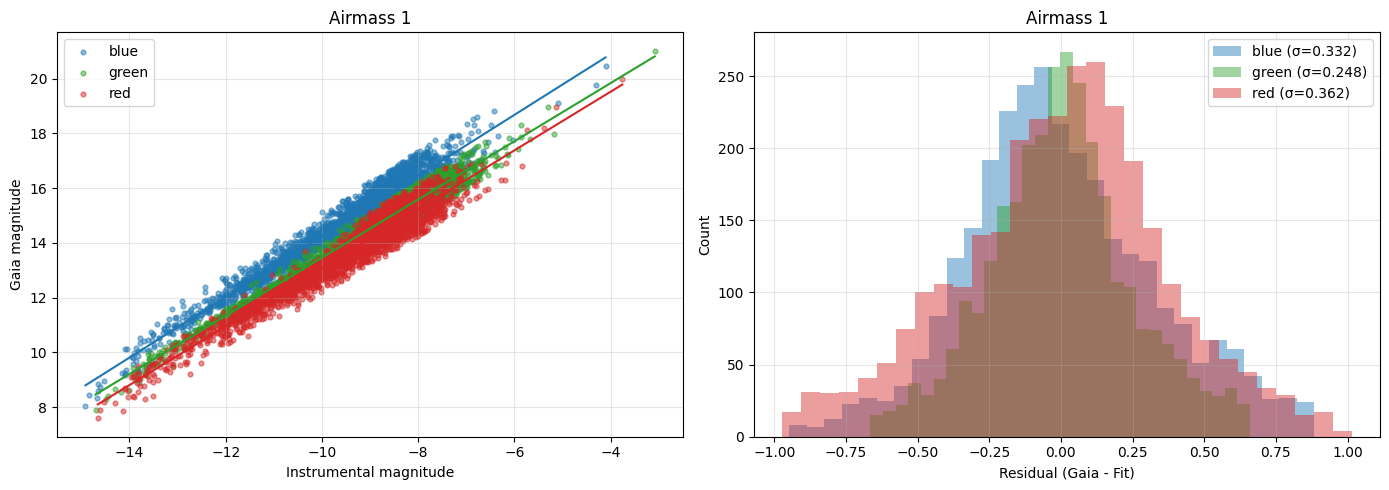

,dataset,sigma_residuals,n_points
0,Airmass 1,0.317627,8990


In [12]:
results = compare_photometry_datasets(
    {
        "Airmass 1": df_matched_1,
        #"Airmass 1 Flat": df_matched_a_1_flat_corrected,
        #"Airmass 2": df_matched_2
        #"Airmass 2 Flat": df_matched_a_2_flat_corrected,
    }
)

display(results)

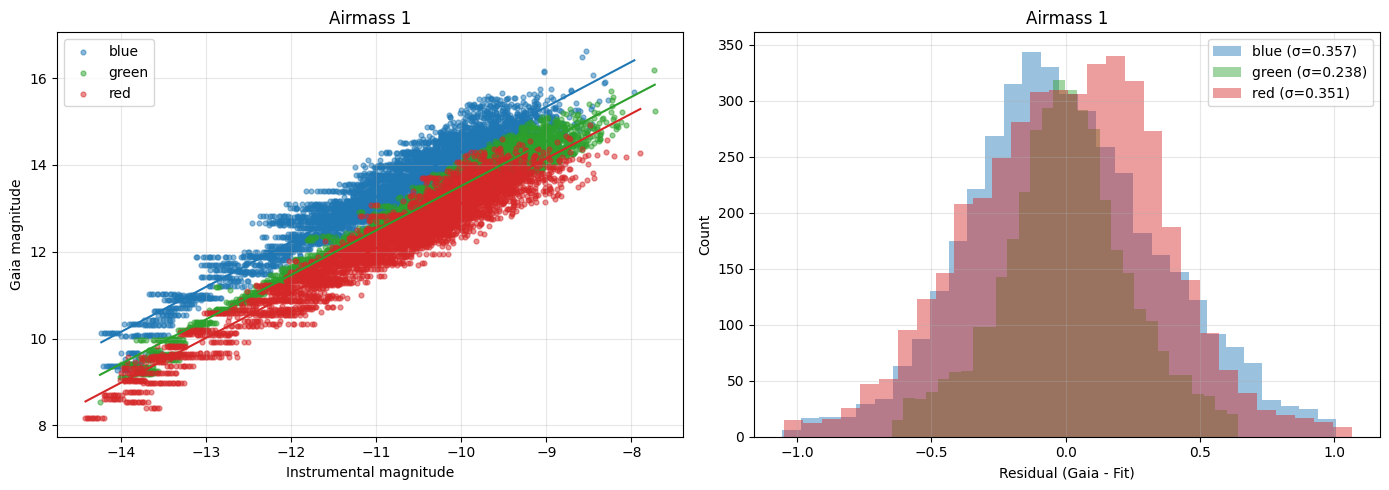

,dataset,sigma_residuals,n_points
0,Airmass 1,0.322018,12210


In [6]:
results = compare_photometry_datasets(
    {
        "Airmass 1": df_matched_1,
        #"Airmass 1 Flat": df_matched_a_1_flat_corrected,
        #"Airmass 2": df_matched_2
        #"Airmass 2 Flat": df_matched_a_2_flat_corrected,
    }
)

display(results)

# Airmass

In [43]:
def add_airmass_to_df(
    df,
    path_col="full_path",
    ra_col="ra_image",
    dec_col="dec_image",
    date_keyword="DATE-OBS",
    lon_keywords=("LONGITUD", "LONGITUDE"),
    lat_keyword="LATITUDE",
    alt_keyword="ALTITUDE",
    min_airmass=1.0,
    max_airmass=5.0,
    verbose=True
):
    """
    Adds airmass to a photometry DataFrame using FITS headers + WCS coords.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe with image-level photometry rows.
    path_col : str
        Column with FITS file paths.
    ra_col, dec_col : str
        Columns with celestial coordinates (deg).
    min_airmass, max_airmass : float
        Valid range for filtering.
    verbose : bool
        Print progress.

    Returns
    -------
    df : pd.DataFrame
        Same dataframe with added 'airmass' column.
    """

    if df.empty:
        raise ValueError("Input dataframe is empty")

    df = df.copy()

    if "airmass" not in df.columns:
        df["airmass"] = np.nan

    valid_mask = df[path_col].astype(str).str.len() > 0
    if not valid_mask.any():
        raise ValueError("No valid file paths found")

    meta_cache = {}

    def read_meta(file_path):
        if file_path in meta_cache:
            return meta_cache[file_path]

        try:
            with fits.open(file_path) as hdul:
                header = hdul[0].header

            date_obs = header.get(date_keyword)
            lon_val = header.get(lon_keywords[0], header.get(lon_keywords[1], 0))
            lat_val = header.get(lat_keyword, 0)
            alt_val = header.get(alt_keyword, 0)

            if lat_val == 0 and lon_val == 0:
                print(f"⚠ Warning: no location found in header for {file_path}")

            if date_obs is None:
                meta_cache[file_path] = None
                return None

            obs_time = Time(date_obs, format="isot", scale="utc")
            location = EarthLocation(
                lat=lat_val * u.deg,
                lon=lon_val * u.deg,
                height=alt_val * u.m
            )

            meta_cache[file_path] = (obs_time, location)
            return meta_cache[file_path]

        except Exception:
            meta_cache[file_path] = None
            return None

    unique_paths = df.loc[valid_mask, path_col].unique()

    if verbose:
        print(f"Computing airmass for {len(unique_paths)} images")

    for i, file_path in enumerate(unique_paths, 1):

        meta = read_meta(file_path)
        if meta is None:
            continue

        obs_time, location = meta

        sub = df[df[path_col] == file_path]

        coords = SkyCoord(
            ra=sub[ra_col].to_numpy(dtype=float) * u.deg,
            dec=sub[dec_col].to_numpy(dtype=float) * u.deg,
        )

        altaz = coords.transform_to(AltAz(obstime=obs_time, location=location))
        alt_deg = altaz.alt.deg
        X = np.where(alt_deg > 0, 1.0 / np.cos(np.radians(90.0 - alt_deg)), np.nan)

        valid = np.isfinite(X) & (X > min_airmass) & (X < max_airmass)  
        

        valid = np.isfinite(X) & (X > min_airmass) & (X < max_airmass)
        print("Raw X stats:", np.nanmin(X), np.nanmax(X))
        print("Valid fraction:", np.mean(np.isfinite(X)))
        print("Valid after filter:", np.sum(valid))

        if not np.any(valid):
            continue

        idx = sub.index[valid]
        df.loc[idx, "airmass"] = X[valid]

        if verbose and (i % 20 == 0 or i == len(unique_paths)):
            done = np.isfinite(df["airmass"]).sum()
            print(f"[{i}/{len(unique_paths)}] airmass assigned to {done} rows")

    return df

In [22]:
df_matched_a_1 = add_airmass_to_df(df_matched_1)


Computing airmass for 58 images
Raw X stats: 1.0637562269238936 1.0665558806354278
Valid fraction: 1.0
Valid after filter: 20
Raw X stats: 1.0637552069985494 1.0665577669486708
Valid fraction: 1.0
Valid after filter: 22
Raw X stats: 1.0634819872358916 1.0661214750320724
Valid fraction: 1.0
Valid after filter: 20
Raw X stats: 1.0568813553234446 1.0598829887205332
Valid fraction: 1.0
Valid after filter: 222
Raw X stats: 1.056897503297427 1.0598840808568861
Valid fraction: 1.0
Valid after filter: 244
Raw X stats: 1.0568983348437182 1.059882009033274
Valid fraction: 1.0
Valid after filter: 227
Raw X stats: 1.0485739384184223 1.0502665785242924
Valid fraction: 1.0
Valid after filter: 280
Raw X stats: 1.0485827059208885 1.0502872906303913
Valid fraction: 1.0
Valid after filter: 314
Raw X stats: 1.0486324228928128 1.0503115913060963
Valid fraction: 1.0
Valid after filter: 303
Raw X stats: 1.0583539519842475 1.0605793306346505
Valid fraction: 1.0
Valid after filter: 321
Raw X stats: 1.05832709

In [44]:
df_matched_a_1

,filename,band,full_path,x_centroid,y_centroid,ra_image,dec_image,flux,mag_inst,source_id,ra_gaia,dec_gaia,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,separation_arcsec,phot_band_mag,airmass
0,20260811T212451_790_blue_band_stack_1.fits,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,223.672103,95.609963,292.055325,71.291879,24801.501953,-10.986195,2263472233423044096,292.055309,71.292211,11.228814,11.56646,10.721264,1.196915,11.56646,1.063778
1,20260811T212451_790_blue_band_stack_1.fits,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,215.211920,104.325675,292.080655,71.300124,130348.984375,-12.787769,2263472267782782976,292.080729,71.300151,9.282100,9.320116,9.191469,0.128869,9.320116,1.063840
2,20260811T212451_790_blue_band_stack_1.fits,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,594.117286,126.586350,290.953791,71.320728,11245.123047,-10.127411,2264197494483808128,290.954049,71.320874,11.883627,12.664521,11.023556,0.603124,12.664521,1.063756
3,20260811T212451_790_blue_band_stack_1.fits,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,525.462330,141.538484,291.157710,71.335585,23660.390625,-10.935055,2264220141847342080,291.157612,71.335515,11.053351,11.415115,10.524224,0.274357,11.415115,1.063890
4,20260811T212451_790_blue_band_stack_1.fits,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,636.031936,145.888172,290.828345,71.338638,11561.864258,-10.157570,2264197739297909120,290.829081,71.338971,11.440431,12.103906,10.65248,1.468284,12.103906,1.063857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11687,20260811T225642_349_red_band_stack_28.fits,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,220.828021,573.310539,345.092639,-11.685360,4232.304688,-9.066442,2603914190528334208,345.092792,-11.685072,14.331155,14.878888,13.628921,1.168899,13.628920555114746,2.840337
11688,20260811T225642_349_red_band_stack_28.fits,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,194.099994,579.614775,345.118651,-11.679332,4317.275879,-9.088024,2603911613547980032,345.118793,-11.679261,14.793383,15.192724,14.228568,0.562073,14.228568077087402,2.840833
11689,20260811T225642_349_red_band_stack_28.fits,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,449.453418,600.337875,344.870098,-11.659655,3025.664307,-8.702051,2604101416742777984,344.869925,-11.659748,14.582130,14.862229,14.130881,0.694073,14.130881309509277,2.826725
11690,20260811T225642_349_red_band_stack_28.fits,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,343.654930,640.668960,344.973063,-11.621205,33466.093750,-11.311512,2604103233513206016,344.973085,-11.621288,12.022760,12.356766,11.5197,0.307339,11.519700050354004,2.826875


# Extinction plot

In [90]:
def fit_extinction(
    df,
    bands=("blue", "green", "red"),
    colors=None,
    sigma=3.0,
    dx=0.02,
    dy=0.02,
    n_bins=50,
    verbose=True,
):
    """
    Fit the atmospheric extinction coefficient (k) and zero point (ZP)
    for each band, using a single dataframe that spans a continuous
    range of airmasses.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain 'band' and 'airmass' columns, plus either:
        - 'delta_m' directly, or
        - 'phot_band_mag' together with 'mag_inst' (delta_m is computed
          as phot_band_mag - mag_inst), or
        - 'mag_inst' together with the Gaia magnitude columns
          ('phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag')
          so that delta_m can be computed per-band.
    bands : tuple of str
        Which bands to fit.
    colors : dict, optional
        Plot color per band.
    sigma : float
        Sigma-clipping threshold (based on a robust MAD estimator).
    dx, dy : float
        Bin width (in airmass, and in delta_m) used to deduplicate
        points that come from the same field-of-view pointing, so a
        single FOV with many stars doesn't dominate the fit.
    n_bins : int
        Number of airmass bins used for the plotted error bars.
    verbose : bool
        Print fit results and row counts.

    Returns
    -------
    dict
        {band: {"k":..., "ZP":..., "k_err":..., "n":...}}
    """
    if colors is None:
        colors = {"blue": "C0", "green": "C2", "red": "C3"}

    df = df.copy()

    if "airmass" not in df.columns:
        raise ValueError(
            "df must contain an 'airmass' column -- run the airmass "
            "calculation step first (or merge it in by 'filename') "
            "before calling fit_extinction."
        )

    # -----------------------------------------------------
    # Compute delta_m if not already present
    # -----------------------------------------------------
    if "delta_m" not in df.columns:
        if "phot_band_mag" in df.columns and "mag_inst" in df.columns:
            # phot_band_mag already holds the correct per-band Gaia
            # reference magnitude (see gaia_crossmatch_folder), so use
            # it directly rather than recomputing it from scratch.
            # Coerce to numeric first -- these columns can come through
            # as strings (e.g. pyarrow-backed string dtype) depending
            # on how the CSV/dataframe was loaded, which would otherwise
            # cause the subtraction below to fail.
            phot_band_mag = pd.to_numeric(df["phot_band_mag"], errors="coerce")
            mag_inst = pd.to_numeric(df["mag_inst"], errors="coerce")
            df["delta_m"] = phot_band_mag - mag_inst
        elif "mag_inst" in df.columns:
            def _gaia_ref(row):
                if row["band"] == "red":
                    return row.get("phot_rp_mean_mag", np.nan)
                elif row["band"] == "blue":
                    return row.get("phot_bp_mean_mag", np.nan)
                else:
                    return row.get("phot_g_mean_mag", np.nan)

            df["_gaia_ref"] = pd.to_numeric(df.apply(_gaia_ref, axis=1), errors="coerce")
            mag_inst = pd.to_numeric(df["mag_inst"], errors="coerce")
            df["delta_m"] = df["_gaia_ref"] - mag_inst
        else:
            raise ValueError(
                "Need one of: 'delta_m', or 'phot_band_mag' + 'mag_inst', "
                "or 'mag_inst' + Gaia magnitude columns"
            )

    # -----------------------------------------------------
    # Helper function
    # -----------------------------------------------------
    def filter_close(x, y):
        # Groups points that fall in the same (airmass, delta_m) bin
        # -- e.g. many stars from the same FOV pointing -- and reduces
        # each group to its median, so a single pointing with many
        # stars doesn't disproportionately weight the fit.
        if len(x) == 0:
            return x, y
        qx = np.round(x / dx).astype(int)
        qy = np.round(y / dy).astype(int)
        tmp = pd.DataFrame({"x": x, "y": y, "qx": qx, "qy": qy})
        g = tmp.groupby(["qx", "qy"], as_index=False)
        xf = g["x"].median()["x"].to_numpy(dtype=float)
        yf = g["y"].median()["y"].to_numpy(dtype=float)
        return xf, yf

    # -----------------------------------------------------
    # Fit and plot per band
    # -----------------------------------------------------
    results = {}
    fig, ax = plt.subplots(figsize=(8, 6))

    for b in bands:
        sub = df[df["band"] == b].copy()
        sub["airmass"] = pd.to_numeric(sub["airmass"], errors="coerce")
        sub["delta_m"] = pd.to_numeric(sub["delta_m"], errors="coerce")
        sub = sub.dropna(subset=["airmass", "delta_m"])

        if len(sub) < 4:
            if verbose:
                print(f"{b}: not enough points ({len(sub)}), skipping")
            continue

        a = sub["airmass"].to_numpy(dtype=float)
        d = sub["delta_m"].to_numpy(dtype=float)

        a, d = filter_close(a, d)

        if len(a) < 4:
            if verbose:
                print(f"{b}: not enough points after FOV deduplication ({len(a)}), skipping")
            continue

        # Iterative sigma-clipping on fit residuals: a plain clip on the
        # raw delta_m values (before fitting) does not account for the
        # airmass trend itself, so a correlated cluster of bad points
        # can survive and still bias the fit. Instead, fit a first pass,
        # clip points far from *that* line, and refit -- repeating until
        # the clipped set stops changing (or a max number of iterations
        # is reached).
        a_fit, d_fit = a, d
        for _ in range(5):
            if len(a_fit) < 4:
                break
            coeffs_i = np.polyfit(a_fit, d_fit, 1)
            resid = d_fit - (coeffs_i[0] * a_fit + coeffs_i[1])
            med_r = np.median(resid)
            mad_r = np.median(np.abs(resid - med_r))
            if mad_r == 0:
                break
            std_r = 1.4826 * mad_r
            keep = np.abs(resid - med_r) <= sigma * std_r
            if keep.sum() == len(a_fit):
                break
            a_fit, d_fit = a_fit[keep], d_fit[keep]

        a, d = a_fit, d_fit

        if len(a) < 4:
            if verbose:
                print(f"{b}: not enough points after residual clipping ({len(a)}), skipping")
            continue

        coeffs, cov = np.polyfit(a, d, 1, cov=True)
        k, zp = coeffs
        k_err = np.sqrt(cov[0, 0])

        results[b] = {
            "k": round(float(k), 4),
            "ZP": round(float(zp), 4),
            "k_err": round(float(k_err), 4),
            "n": len(a),
        }

        if verbose:
            print(f"{b:5s}: k = {k:.4f} ± {k_err:.4f}  |  ZP = {zp:.4f}  |  n = {len(a)}")

        bins_local = min(n_bins, max(2, len(a)))
        bin_stats = (
            pd.DataFrame({"a": a, "d": d})
            .groupby(pd.cut(a, bins_local))
            .agg(x=("a", "mean"), y=("d", "mean"), e=("d", "std"))
            .dropna()
            .reset_index(drop=True)
        )

        ax.errorbar(
            bin_stats["x"], bin_stats["y"], yerr=bin_stats["e"],
            fmt="o", capsize=3,
            color=colors.get(b, "black"),
            label=f"{b} band: k={k:.3f}±{k_err:.3f}, ZP={zp:.3f}",
        )

        xx = np.linspace(a.min(), a.max(), 200)
        ax.plot(xx, k * xx + zp, color=colors.get(b, "black"), lw=2)

    ax.set_xlabel("Airmass (X)")
    ax.set_ylabel(r"$m_{Gaia} - m_{inst}$")
    ax.set_title("Extinction fit by band")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    return results

blue : k = -0.2345 ± 0.0250  |  ZP = 24.7740  |  n = 1174
green: k = -0.1761 ± 0.0220  |  ZP = 23.8457  |  n = 1058
red  : k = -0.2050 ± 0.0245  |  ZP = 23.4659  |  n = 1155


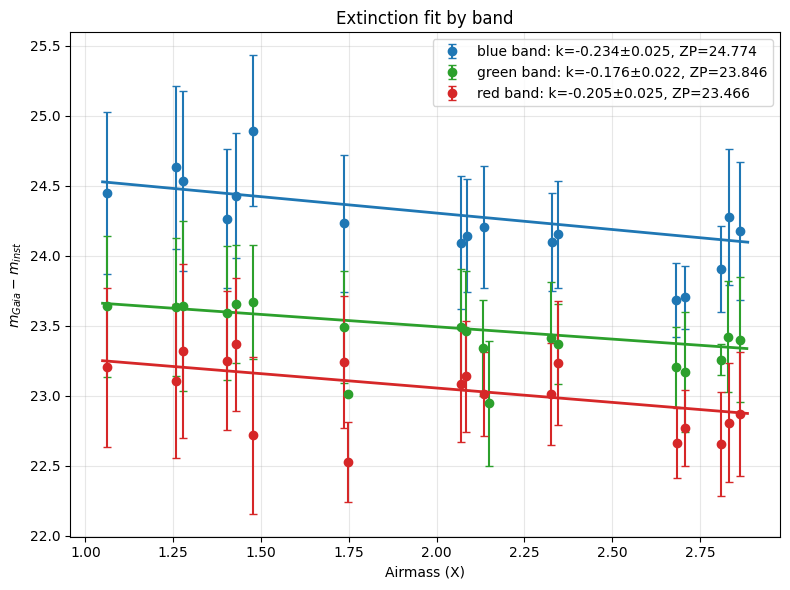

{'blue': {'k': -0.2345, 'ZP': 24.774, 'k_err': 0.025, 'n': 1174},
 'green': {'k': -0.1761, 'ZP': 23.8457, 'k_err': 0.022, 'n': 1058},
 'red': {'k': -0.205, 'ZP': 23.4659, 'k_err': 0.0245, 'n': 1155}}

In [16]:
fit_extinction(
    df=df_matched_a_1
)

blue : k = -16.3619 ± 4.0854  |  ZP = 41.8166  |  n = 408
green: k = -3.9286 ± 3.0093  |  ZP = 27.7297  |  n = 308
red  : k = 5.1275 ± 2.9896  |  ZP = 17.5896  |  n = 346


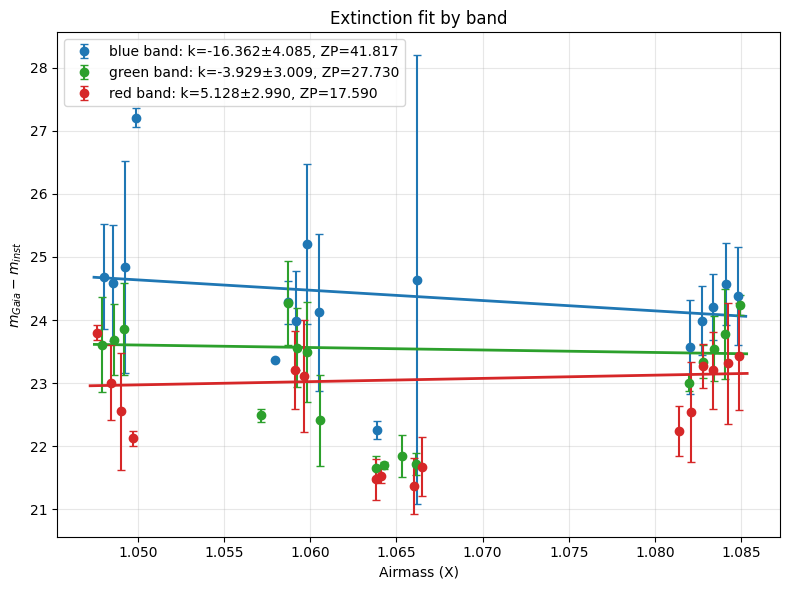

{'blue': {'k': -16.3619, 'ZP': 41.8166, 'k_err': 4.0854, 'n': 408},
 'green': {'k': -3.9286, 'ZP': 27.7297, 'k_err': 3.0093, 'n': 308},
 'red': {'k': 5.1275, 'ZP': 17.5896, 'k_err': 2.9896, 'n': 346}}

In [11]:
fit_extinction(
    df=df_matched_a_1
)

# Color correction

In [ ]:
def add_color_correction(df, band_col="band", verbose=True):
    """
    Add color correction columns to a photometry DataFrame.

    Computes BP-RP from Gaia columns, applies a 4th-degree polynomial
    correction per Bayer band, then recomputes delta_m using phot_band_mag
    as the band-matched Gaia reference.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain: band, mag_inst, phot_bp_mean_mag, phot_rp_mean_mag,
        phot_band_mag
    band_col : str
        Column with band labels ("blue", "green", "red")
    verbose : bool
        Print per-band summary stats

    Returns
    -------
    pd.DataFrame with added columns:
        - bp_rp          : Gaia BP - RP color index
        - color_corr     : polynomial correction value
        - delta_m        : phot_band_mag - mag_inst  (band-matched)
        - delta_m_corr   : delta_m + color_corr
    """

    COEFFS = {
        "red":   (-0.00403,  0.01485,  0.06865, -0.40732, -0.01263),
        "blue":  ( 0.00932, -0.04559, -0.05142,  0.11676,  0.01417),
        "green": ( 0.00241, -0.02134,  0.05489, -0.12330, -0.03029),
    }

    df = df.copy()

    # ensure numeric
    for col in ["mag_inst", "phot_bp_mean_mag", "phot_rp_mean_mag", "phot_band_mag"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # compute BP-RP
    df["bp_rp"] = df["phot_bp_mean_mag"] - df["phot_rp_mean_mag"]

    # color correction per band
    df["color_corr"] = np.nan

    for band, (a, b, c, d, e) in COEFFS.items():
        mask = df[band_col] == band
        if mask.sum() == 0:
            continue
        x = df.loc[mask, "bp_rp"]
        df.loc[mask, "color_corr"] = a*x**4 + b*x**3 + c*x**2 + d*x + e

    # delta_m using band-matched Gaia reference
    df["delta_m"]      = df["phot_band_mag"] - df["mag_inst"]
    df["delta_m_corr"] = df["delta_m"] + df["color_corr"]

    if verbose:
        for band in df[band_col].dropna().unique():
            sub = df[df[band_col] == band]
            print(f"{band:6s}: n={len(sub):4d} | "
                  f"bp_rp=[{sub['bp_rp'].min():.2f}, {sub['bp_rp'].max():.2f}] | "
                  f"color_corr mean={sub['color_corr'].mean():.4f} | "
                  f"delta_m mean={sub['delta_m'].mean():.4f}")

    n_missing = df["color_corr"].isna().sum()
    if n_missing > 0:
        unknown = set(df.loc[df["color_corr"].isna(), band_col].dropna().unique()) - set(COEFFS)
        if unknown:
            print(f"⚠ {n_missing} rows have no correction (unknown bands: {unknown})")

    return df

In [51]:
df_matched_a_1_swarp_color = add_color_correction(df_matched_1 )
#df_matched_a_2_swarp_color = add_color_correction(df_matched_a_2_swarp)
#df_matched_a_1_flat_corrected_color = add_color_correction(df_matched_a_1_flat_corrected)
#df_matched_a_2_flat_corrected_color = add_color_correction(df_matched_a_2_flat_corrected)
#df_matched_a_1_swarp_no_bkg_color = add_color_correction(df_matched_a_1_swarp_no_bkg)
#df_matched_a_2_swarp_no_bkg_color = add_color_correction(df_matched_a_2_swarp_no_bkg)


blue  : n=3739 | bp_rp=[-0.37, 6.85] | color_corr mean=-0.0050 | delta_m mean=24.3975
green : n=4189 | bp_rp=[-0.37, 6.85] | color_corr mean=-0.1370 | delta_m mean=23.5621
red   : n=3764 | bp_rp=[-0.37, 6.85] | color_corr mean=-0.3786 | delta_m mean=23.1780


In [95]:
df_matched_a_1_swarp_color["airmass"] = df_matched_a_1["airmass"].values

In [96]:
df_matched_a_1_swarp_color


,filename,band,full_path,x_centroid,y_centroid,ra_image,dec_image,flux,mag_inst,source_id,...,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,separation_arcsec,phot_band_mag,airmass,bp_rp,color_corr,delta_m,delta_m_corr
0,20260811T212451_790_blue_band_stack_1.fits,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,223.672103,95.609963,292.055325,71.291879,24801.501953,-10.986195,2263472233423044096,...,11.228814,11.566460,10.721264,1.196915,11.566460,1.063778,0.845196,0.053353,22.552655,22.606008
1,20260811T212451_790_blue_band_stack_1.fits,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,215.211920,104.325675,292.080655,71.300124,130348.984375,-12.787769,2263472267782782976,...,9.282100,9.320116,9.191469,0.128869,9.320116,1.063840,0.128647,0.028245,22.107885,22.136131
2,20260811T212451_790_blue_band_stack_1.fits,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,594.117286,126.586350,290.953791,71.320728,11245.123047,-10.127411,2264197494483808128,...,11.883627,12.664521,11.023556,0.603124,12.664521,1.063756,1.640965,-0.066564,22.791932,22.725368
3,20260811T212451_790_blue_band_stack_1.fits,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,525.462330,141.538484,291.157710,71.335585,23660.390625,-10.935055,2264220141847342080,...,11.053351,11.415115,10.524224,0.274357,11.415115,1.063890,0.890891,0.051014,22.350170,22.401184
4,20260811T212451_790_blue_band_stack_1.fits,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,636.031936,145.888172,290.828345,71.338638,11561.864258,-10.157570,2264197739297909120,...,11.440431,12.103906,10.652480,1.468284,12.103906,1.063857,1.451426,-0.022721,22.261476,22.238755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11687,20260811T225642_349_red_band_stack_28.fits,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,220.828021,573.310539,345.092639,-11.685360,4232.304688,-9.066442,2603914190528334208,...,14.331155,14.878888,13.628921,1.168899,13.628921,2.840337,1.249967,-0.395343,22.695363,22.300020
11688,20260811T225642_349_red_band_stack_28.fits,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,194.099994,579.614775,345.118651,-11.679332,4317.275879,-9.088024,2603911613547980032,...,14.793383,15.192724,14.228568,0.562073,14.228568,2.840833,0.964156,-0.331706,23.316592,22.984886
11689,20260811T225642_349_red_band_stack_28.fits,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,449.453418,600.337875,344.870098,-11.659655,3025.664307,-8.702051,2604101416742777984,...,14.582130,14.862229,14.130881,0.694073,14.130881,2.826725,0.731348,-0.269148,22.832932,22.563785
11690,20260811T225642_349_red_band_stack_28.fits,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,343.654930,640.668960,344.973063,-11.621205,33466.093750,-11.311512,2604103233513206016,...,12.022760,12.356766,11.519700,0.307339,11.519700,2.826875,0.837066,-0.298751,22.831212,22.532461


## Magnitudes color correction

In [87]:
def compare_photometry_datasets_color(
    datasets,
    sigma_clip=True,
    close_filter=True,
    dx=0.02,
    dy=0.02,
    bins=30
):
    """
    Parameters
    ----------
    datasets : dict
        {
            "Airmass1": df1,
            "Airmass1 Flat": df2,
            ...
        }
    """

    fig, axes = plt.subplots(
        len(datasets),
        2,
        figsize=(14, 5 * len(datasets))
    )

    if len(datasets) == 1:
        axes = np.array([axes])

    results = []

    for row, (label, df) in enumerate(datasets.items()):

        ax_fit = axes[row, 0]
        ax_hist = axes[row, 1]

        tmp = df.copy()

        for col in ["mag_inst", "color_corr", "phot_g_mean_mag", "phot_bp_mean_mag", "phot_rp_mean_mag"]:
            if col in tmp.columns:
                tmp[col] = pd.to_numeric(tmp[col], errors="coerce")

        tmp["gaia_mag"] = np.where(
            tmp["band"] == "green",
            tmp["phot_g_mean_mag"],
            np.where(
                tmp["band"] == "blue",
                tmp["phot_bp_mean_mag"],
                tmp["phot_rp_mean_mag"]
            )
        )

        residuals_all = []

        for band, color in zip(
            ["blue", "green", "red"],
            ["C0", "C2", "C3"]
        ):

            sub = tmp[tmp["band"] == band]

            x = sub["mag_inst"].values + sub["color_corr"].values
            y = sub["gaia_mag"].values

            mask = np.isfinite(x) & np.isfinite(y)
            x = x[mask]
            y = y[mask]

            if len(x) < 3:
                continue

            if close_filter:
                x, y = filter_close_points(
                    x, y,
                    dx=dx,
                    dy=dy
                )

            if sigma_clip:
                x, y = sigma_clip_line(x, y)

            if len(x) < 3:
                continue

            slope, intercept = np.polyfit(x, y, 1)

            y_fit = slope * x + intercept
            residuals = y - y_fit

            residuals_all.extend(residuals)

            ax_fit.scatter(
                x,
                y,
                s=12,
                alpha=0.5,
                color=color,
                label=band
            )

            xx = np.linspace(
                x.min(),
                x.max(),
                100
            )

            ax_fit.plot(
                xx,
                slope * xx + intercept,
                color=color
            )

        residuals_all = np.array(residuals_all)

        sigma = np.std(residuals_all)

        results.append({
            "dataset": label,
            "sigma_residuals": sigma,
            "n_points": len(residuals_all)
        })

        ax_fit.set_title(label)
        ax_fit.set_xlabel("Instrumental magnitude")
        ax_fit.set_ylabel("Gaia magnitude")
        ax_fit.grid(alpha=0.3)
        ax_fit.legend()

        ax_hist.hist(
            residuals_all,
            bins=bins
        )

        ax_hist.set_title(
            f"{label}\nσ = {sigma:.4f} mag"
        )

        ax_hist.set_xlabel("Residual")
        ax_hist.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

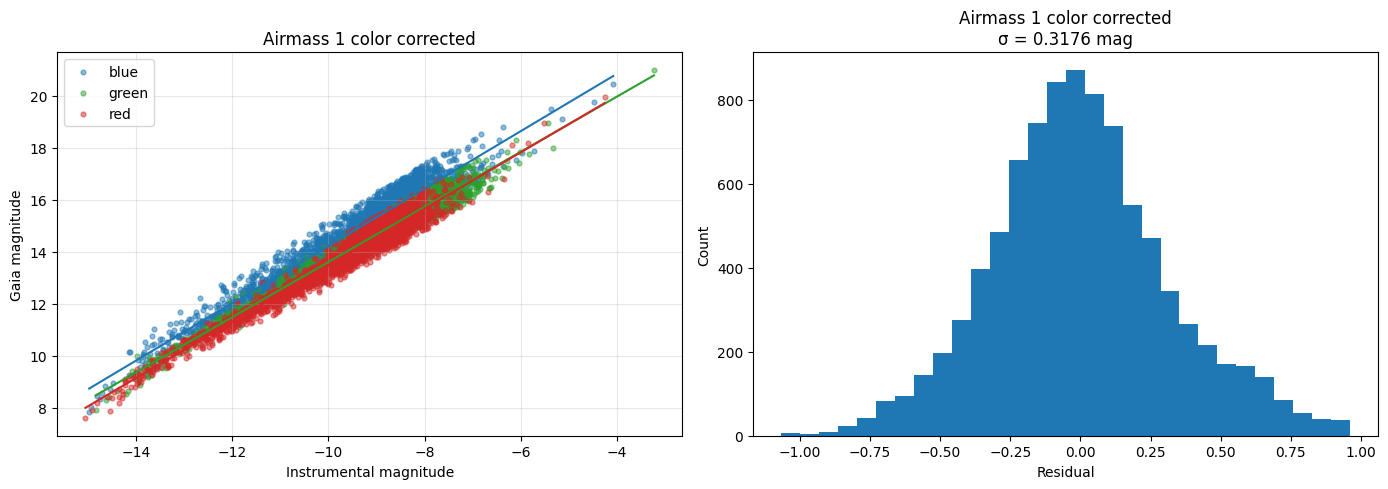

None

In [88]:
results = compare_photometry_datasets_color(
    {
        "Airmass 1 color corrected": df_matched_a_1_swarp_color
    }
)

display(results)

# Extinction plot with color correction

In [61]:
df_matched_a_1_swarp_color.to_csv('df_matched_a_1_swarp_color.csv', index=False)


In [64]:
def fit_extinction_one_dataframe_color(
    df,
    stats_df=None,
    target_gain=0.230365,
    bands=("blue", "green", "red"),
    colors=None,
    sigma=3.0,
    dx=0.02,
    dy=0.02,
    n_bins=50,
    verbose=True
):
    """
    Fit atmospheric extinction using a single dataframe containing
    measurements over a range of airmasses.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataframe containing all measurements.

    stats_df : pandas.DataFrame, optional
        Dataframe containing gain information. Must contain:
        filename, band, gain

    target_gain : float
        Gain value to select.

    bands : tuple
        Bands to process.

    colors : dict, optional
        Matplotlib colors for each band.

    sigma : float
        Sigma threshold for MAD-based sigma clipping.

    dx, dy : float
        Grid spacing used to combine very close points.

    n_bins : int
        Maximum number of bins used for plotting.

    verbose : bool
        Print fit results.

    Returns
    -------
    results : dict
        Extinction coefficient, zero point, uncertainty, and number
        of retained points for each band.
    """

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    if colors is None:
        colors = {
            "blue": "C0",
            "green": "C2",
            "red": "C3"
        }

    # ---------------------------------------------------------------
    # Copy dataframe
    # ---------------------------------------------------------------

    df = df.copy()

    # ---------------------------------------------------------------
    # Construct delta_m_corr if it does not already exist
    # ---------------------------------------------------------------

    if "delta_m_corr" not in df.columns:

        if "mag_inst" not in df.columns:
            raise ValueError(
                "Need either 'delta_m_corr' or 'mag_inst' column"
            )

        def _gaia_ref(row):

            if row["band"] == "red":
                return row.get(
                    "phot_rp_mean_mag",
                    np.nan
                )

            elif row["band"] == "blue":
                return row.get(
                    "phot_bp_mean_mag",
                    np.nan
                )

            else:
                return row.get(
                    "phot_g_mean_mag",
                    np.nan
                )

        df["_gaia_ref"] = df.apply(
            _gaia_ref,
            axis=1
        )

        df["delta_m_corr"] = (
            -df["mag_inst"]
            + df["_gaia_ref"]
        )

    # ---------------------------------------------------------------
    # Optional gain filtering
    # ---------------------------------------------------------------

    if stats_df is not None and not stats_df.empty:

        stats_gain = stats_df[
            ["filename", "band", "gain"]
        ].copy()

        df = df.merge(
            stats_gain,
            on=["filename", "band"],
            how="left"
        )

        df["gain_num"] = pd.to_numeric(
            df["gain"],
            errors="coerce"
        )

        df = df[
            np.isclose(
                df["gain_num"],
                target_gain,
                atol=1e-6
            )
        ].copy()

        if df.empty:
            raise ValueError(
                f"No rows remain after filtering "
                f"for gain={target_gain}"
            )

        if verbose:
            print(
                f"After gain filter: {len(df)} rows"
            )

    # ---------------------------------------------------------------
    # Robust sigma clipping
    # ---------------------------------------------------------------

    def sigma_clip(x, y):

        if len(x) < 3:
            return x, y

        med = np.median(y)

        mad = np.median(
            np.abs(y - med)
        )

        if mad == 0:
            return x, y

        std = 1.4826 * mad

        keep = (
            np.abs(y - med)
            <= sigma * std
        )

        return x[keep], y[keep]

    # ---------------------------------------------------------------
    # Combine very close points
    # ---------------------------------------------------------------

    def filter_close(x, y):

        if len(x) == 0:
            return x, y

        qx = np.round(
            x / dx
        ).astype(int)

        qy = np.round(
            y / dy
        ).astype(int)

        tmp = pd.DataFrame({
            "x": x,
            "y": y,
            "qx": qx,
            "qy": qy
        })

        grouped = (
            tmp
            .groupby(
                ["qx", "qy"],
                as_index=False
            )
            .agg(
                x=("x", "median"),
                y=("y", "median")
            )
        )

        return (
            grouped["x"].to_numpy(dtype=float),
            grouped["y"].to_numpy(dtype=float)
        )

    # ---------------------------------------------------------------
    # Fit
    # ---------------------------------------------------------------

    results = {}

    fig, ax = plt.subplots(
        figsize=(8, 6)
    )

    for b in bands:

        sub = df[
            df["band"] == b
        ].copy()

        sub["airmass"] = pd.to_numeric(
            sub["airmass"],
            errors="coerce"
        )

        sub["delta_m_corr"] = pd.to_numeric(
            sub["delta_m_corr"],
            errors="coerce"
        )

        sub = sub.dropna(
            subset=[
                "airmass",
                "delta_m_corr"
            ]
        )

        if len(sub) < 4:

            if verbose:
                print(
                    f"{b}: not enough points "
                    f"({len(sub)}), skipping"
                )

            continue

        # Raw arrays
        a = sub[
            "airmass"
        ].to_numpy(dtype=float)

        d = sub[
            "delta_m_corr"
        ].to_numpy(dtype=float)

        # Combine nearly identical points
        a, d = filter_close(a, d)

        # Remove outliers
        a, d = sigma_clip(a, d)

        if len(a) < 4:

            if verbose:
                print(
                    f"{b}: not enough points "
                    f"after filtering"
                )

            continue

        # -----------------------------------------------------------
        # Linear extinction fit
        #
        # delta_m = k X + ZP
        # -----------------------------------------------------------

        coeffs, cov = np.polyfit(
            a,
            d,
            1,
            cov=True
        )

        k, zp = coeffs

        k_err = np.sqrt(
            cov[0, 0]
        )

        zp_err = np.sqrt(
            cov[1, 1]
        )

        results[b] = {
            "k": round(
                float(k),
                4
            ),
            "k_err": round(
                float(k_err),
                4
            ),
            "ZP": round(
                float(zp),
                4
            ),
            "ZP_err": round(
                float(zp_err),
                4
            ),
            "n": len(a)
        }

        if verbose:

            print(
                f"{b:5s}: "
                f"k = {k:.4f} ± {k_err:.4f}  |  "
                f"ZP = {zp:.4f} ± {zp_err:.4f}  |  "
                f"n = {len(a)}"
            )

        # -----------------------------------------------------------
        # Bin only for visualization
        # -----------------------------------------------------------

        bins_local = min(
            n_bins,
            max(2, len(a))
        )

        bin_stats = (
            pd.DataFrame({
                "a": a,
                "d": d
            })
            .groupby(
                pd.cut(
                    a,
                    bins_local
                ),
                observed=False
            )
            .agg(
                x=("a", "mean"),
                y=("d", "mean"),
                e=("d", "std"),
                n=("d", "size")
            )
            .dropna(
                subset=["x", "y"]
            )
            .reset_index(drop=True)
        )

        # -----------------------------------------------------------
        # Plot binned observations
        # -----------------------------------------------------------

        ax.errorbar(
            bin_stats["x"],
            bin_stats["y"],
            yerr=bin_stats["e"],
            fmt="o",
            capsize=3,
            color=colors.get(
                b,
                "black"
            ),
            label=(f"{b} "
            f"(k={k:.3f}±{k_err:.3f}, "
            f"ZP={zp:.3f}±{zp_err:.3f})"
                )
        )

        # -----------------------------------------------------------
        # Plot fitted line
        # -----------------------------------------------------------

        xx = np.linspace(
            a.min(),
            a.max(),
            200
        )

        ax.plot(
            xx,
            k * xx + zp,
            color=colors.get(
                b,
                "black"
            ),
            lw=2
        )

    # ---------------------------------------------------------------
    # Figure formatting
    # ---------------------------------------------------------------

    ax.set_xlabel(
        "Airmass (X)"
    )

    ax.set_ylabel(
        r"$\Delta m_{\rm corr}$"
    )

    ax.set_title(
        "Extinction fit with color correction"
    )

    ax.grid(
        alpha=0.3
    )

    ax.legend()

    plt.tight_layout()
    plt.show()

    return results

blue : k = -0.2055 ± 0.0258  |  ZP = 24.7314 ± 0.0476  |  n = 1124
green: k = -0.1433 ± 0.0241  |  ZP = 23.6519 ± 0.0450  |  n = 1088
red  : k = -0.1436 ± 0.0279  |  ZP = 22.9683 ± 0.0513  |  n = 1216


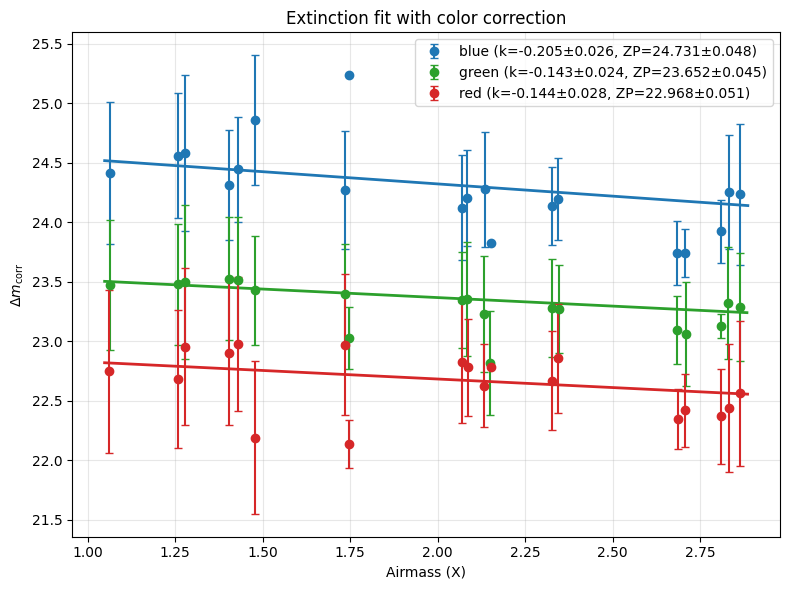

In [65]:
k_coeffs = fit_extinction_one_dataframe_color(
    df_matched_a_1_swarp_color
)

# Statistics and Skyglow calculation

In [17]:
def compute_background_stats(
    folder,
    output_csv="background_stats.csv",
    file_pattern="*.fits",
    gain_keyword="GAIN",
    exptime_keyword="EXPTIME",
    dateobs_keyword="DATE-OBS",
    sigma=3.0,
    bands=("red_band", "green_band", "blue_band"),
    timezone="Europe/Berlin",
):
    """
    Walk a folder (recursively) for FITS images, compute sigma-clipped
    background statistics for each, and save the result as a CSV.

    Parameters
    ----------
    folder : str or Path
        Root folder to search for FITS files (searched recursively).

    output_csv : str or Path
        Filename/path for the output CSV.

    file_pattern : str
        Glob pattern for the files to include, e.g. "*.fits".

    gain_keyword : str
        FITS header keyword for detector gain.

    exptime_keyword : str
        FITS header keyword for exposure time.

    dateobs_keyword : str
        FITS header keyword containing the observation date/time.
        Usually "DATE-OBS".

    sigma : float
        Sigma-clipping threshold used for the background statistics.

    bands : tuple of str
        Folder-name substrings used to identify the band of each file.

    timezone : str
        Timezone used to calculate the local observation time.
        Default is "Europe/Berlin".

    Returns
    -------
    pd.DataFrame
        One row per FITS file, with columns:
        filename, band, full_path, date_obs_utc, date_obs_local,
        gain, exp_time, bg_median, bg_std, bg_mean.
    """

    folder = Path(folder)
    output_csv = Path(output_csv)

    if not folder.exists():
        raise FileNotFoundError(f"{folder} does not exist")

    fits_files = sorted(folder.rglob(file_pattern))

    print(
        f"Found {len(fits_files)} files matching "
        f"'{file_pattern}' in {folder}"
    )

    rows = []

    for i, fits_path in enumerate(fits_files, 1):

        file_str = str(fits_path)

        # ---------------------------------------------------------
        # Identify band
        # ---------------------------------------------------------
        band = "unknown"

        for b in bands:
            if b in file_str:
                band = b.replace("_band", "")
                break

        try:

            # -----------------------------------------------------
            # Open FITS
            # -----------------------------------------------------
            with fits.open(fits_path) as hdul:

                header = hdul[0].header
                data = hdul[0].data

            if data is None:

                print(
                    f"  [{i}/{len(fits_files)}] "
                    f"{fits_path.name}: no data, skipping"
                )

                continue

            # -----------------------------------------------------
            # Background statistics
            # -----------------------------------------------------
            mean, median, std = sigma_clipped_stats(
                data.astype(np.float32),
                sigma=sigma
            )

            # -----------------------------------------------------
            # Header information
            # -----------------------------------------------------
            gain = header.get(
                gain_keyword,
                np.nan
            )

            exp_time = header.get(
                exptime_keyword,
                np.nan
            )

            # Observation time
            date_obs = header.get(
                dateobs_keyword,
                None
            )

            # -----------------------------------------------------
            # Convert DATE-OBS to UTC and local time
            # -----------------------------------------------------
            date_obs_utc = pd.to_datetime(
                date_obs,
                errors="coerce",
                utc=True
            )

            if pd.notna(date_obs_utc):

                date_obs_local = date_obs_utc.tz_convert(
                    timezone
                )

            else:

                date_obs_local = pd.NaT

            # -----------------------------------------------------
            # Save row
            # -----------------------------------------------------
            rows.append({

                "filename": fits_path.name,

                "band": band,

                "full_path": str(fits_path),

                # Original observation time
                "date_obs": date_obs,

                # Explicit UTC time
                "date_obs_utc": date_obs_utc,

                # Local time
                "date_obs_local": date_obs_local,

                "gain": gain,

                "exp_time": exp_time,

                "bg_median": median,

                "bg_std": std,

                "bg_mean": mean,
            })

        except Exception as e:

            print(
                f"  [{i}/{len(fits_files)}] "
                f"{fits_path.name}: ERROR -- {e}"
            )

            continue

    # -------------------------------------------------------------
    # Create DataFrame
    # -------------------------------------------------------------
    df = pd.DataFrame(rows)

    if df.empty:

        raise RuntimeError(
            "No valid background statistics were computed -- "
            "check file_pattern and header keywords."
        )

    # -------------------------------------------------------------
    # Convert datetime columns to strings before saving
    # -------------------------------------------------------------
    if "date_obs_utc" in df.columns:

        df["date_obs_utc"] = df["date_obs_utc"].astype(str)

    if "date_obs_local" in df.columns:

        df["date_obs_local"] = df["date_obs_local"].astype(str)

    # -------------------------------------------------------------
    # Save CSV
    # -------------------------------------------------------------
    df.to_csv(
        output_csv,
        index=False
    )

    print(
        f"\nSaved {len(df)} rows to {output_csv}"
    )

    return df

In [18]:
bg_df = compute_background_stats(
    folder="/mnt/c/Users/catal/Downloads/skyglow_evscope/wcs_solved_flat_corrected",
    output_csv="bkg_stats_aug_12_2.csv",
    file_pattern="*.fits",
)

Found 1545 files matching '*.fits' in /mnt/c/Users/catal/Downloads/skyglow_evscope/wcs_solved_flat_corrected

Saved 1545 rows to bkg_stats_aug_12_2.csv


In [12]:
def plot_sky_magnitude_diagnostics(
    sky_mag_df,
    df_matched=None,
    timezone="Europe/Berlin",
    figsize_airmass=(8, 5),
    figsize_time=(10, 5),
):
    """
    Create diagnostic plots of sky magnitude versus airmass and time.

    Parameters
    ----------
    sky_mag_df : pandas.DataFrame
        DataFrame containing the sky-magnitude measurements.
        Required columns:
            filename
            band
            m_sky

        Optional columns:
            sigma_m
            gain
            exp_time

    df_matched : pandas.DataFrame, optional
        DataFrame containing source-matching information.
        Used to obtain airmass and FITS file paths for DATE-OBS.
        Expected columns:
            filename or full_path
            band
            airmass
            full_path

    timezone : str
        Timezone used to display DATE-OBS.
        Default is "Europe/Berlin".

    figsize_airmass : tuple
        Figure size for the airmass plot.

    figsize_time : tuple
        Figure size for the time plot.

    Returns
    -------
    pandas.DataFrame
        Copy of sky_mag_df containing the added airmass and
        local observation-time information where available.
    """

    # ---------------------------------------------------------
    # Check input
    # ---------------------------------------------------------
    if sky_mag_df is None or sky_mag_df.empty:
        raise ValueError("sky_mag_df is missing or empty.")

    plot_df = sky_mag_df.copy()

    # ---------------------------------------------------------
    # Ensure numeric columns
    # ---------------------------------------------------------
    for c in ["m_sky", "sigma_m", "gain", "exp_time"]:
        if c in plot_df.columns:
            plot_df[c] = pd.to_numeric(
                plot_df[c],
                errors="coerce"
            )

    # ---------------------------------------------------------
    # Add airmass and DATE-OBS
    # ---------------------------------------------------------
    if df_matched is not None and not df_matched.empty:

        aux = df_matched.copy()

        # Create filename from full_path if necessary
        if "full_path" in aux.columns:
            aux["filename"] = (
                aux["full_path"]
                .astype(str)
                .map(lambda p: Path(p).name)
            )

        # -----------------------------------------------------
        # Airmass
        # -----------------------------------------------------
        required = {"filename", "band", "airmass"}

        if required.issubset(aux.columns):

            aux["airmass"] = pd.to_numeric(
                aux["airmass"],
                errors="coerce"
            )

            aux = aux.dropna(
                subset=["filename", "band"]
            )

            # One representative airmass per file
            airmass_file = (
                aux.groupby(
                    ["filename", "band"],
                    as_index=False
                )["airmass"]
                .median()
            )

            plot_df = plot_df.merge(
                airmass_file,
                on=["filename", "band"],
                how="left",
                suffixes=("", "_matched")
            )

        # -----------------------------------------------------
        # DATE-OBS
        # -----------------------------------------------------
        if {"filename", "band", "full_path"}.issubset(aux.columns):

            path_map = (
                aux.dropna(subset=["full_path"])
                .drop_duplicates(
                    subset=["filename", "band"]
                )
            )

            date_rows = []

            for row in path_map.itertuples(index=False):

                fpath = Path(row.full_path)
                date_obs = None

                try:
                    with fits.open(fpath) as hdul:
                        date_obs = hdul[0].header.get(
                            "DATE-OBS"
                        )

                except Exception:
                    pass

                date_rows.append({
                    "filename": row.filename,
                    "band": row.band,
                    "date_obs": date_obs
                })

            date_df = pd.DataFrame(date_rows)

            if not date_df.empty:

                # Parse DATE-OBS as UTC
                date_df["date_obs_utc"] = pd.to_datetime(
                    date_df["date_obs"],
                    errors="coerce",
                    utc=True
                )

                # Convert to local time
                date_df["date_obs_local"] = (
                    date_df["date_obs_utc"]
                    .dt.tz_convert(timezone)
                )

                plot_df = plot_df.merge(
                    date_df[
                        [
                            "filename",
                            "band",
                            "date_obs_local"
                        ]
                    ],
                    on=["filename", "band"],
                    how="left"
                )

    # ---------------------------------------------------------
    # Plot style
    # ---------------------------------------------------------
    band_colors = {
        "blue": "C0",
        "green": "C2",
        "red": "C3"
    }

    # ---------------------------------------------------------
    # 1. Sky magnitude vs airmass
    # ---------------------------------------------------------
    if (
        "airmass" in plot_df.columns
        and plot_df["airmass"].notna().any()
    ):

        plt.figure(figsize=figsize_airmass)

        for band, color in band_colors.items():

            sel = (
                (plot_df["band"] == band)
                & np.isfinite(plot_df["airmass"])
                & np.isfinite(plot_df["m_sky"])
            )

            if sel.any():

                plt.scatter(
                    plot_df.loc[sel, "airmass"],
                    plot_df.loc[sel, "m_sky"],
                    s=16,
                    alpha=0.55,
                    color=color,
                    label=band
                )

        plt.gca().invert_yaxis()
        plt.ylim(21, 17)

        plt.xlabel("Airmass")
        plt.ylabel(
            r"Sky magnitude (mag arcsec$^{-2}$ proxy)"
        )
        plt.title("Sky Magnitude vs Airmass")

        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    else:
        print("No valid airmass data available.")

    # ---------------------------------------------------------
    # 2. Sky magnitude vs time
    # ---------------------------------------------------------
    if (
        "date_obs_local" in plot_df.columns
        and plot_df["date_obs_local"].notna().any()
    ):

        plt.figure(figsize=figsize_time)

        for band, color in band_colors.items():

            sel = (
                (plot_df["band"] == band)
                & plot_df["date_obs_local"].notna()
                & np.isfinite(plot_df["m_sky"])
            )

            if sel.any():

                plt.scatter(
                    plot_df.loc[sel, "date_obs_local"],
                    plot_df.loc[sel, "m_sky"],
                    s=14,
                    alpha=0.55,
                    color=color,
                    label=band
                )

        plt.gca().invert_yaxis()
        #plt.ylim(20, 18)

        plt.xlabel(
            f"DATE-OBS ({timezone})"
        )
        plt.ylabel(
            r"Sky magnitude (mag arcsec$^{-2}$ proxy)"
        )
        plt.title(
            f"Sky Magnitude vs Time ({timezone})"
        )

        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    else:
        print("No valid DATE-OBS data available.")

    return plot_df

In [99]:
sky_mag_df = pd.read_csv(
    "/home/catal/code/pollution/august_12_obs/bkg_stats_aug_12_2.csv"
)

# Compute one airmass value per image from its WCS reference position.
def image_airmass(file_path):
    try:
        header = fits.getheader(file_path)
        date_obs = header.get("DATE-OBS")
        ra = header.get("CRVAL1")
        dec = header.get("CRVAL2")
        if date_obs is None or ra is None or dec is None:
            return np.nan

        location = EarthLocation(
            lat=header["LATITUDE"] * u.deg,
            lon=header["LONGITUD"] * u.deg,
            height=header.get("ALTITUDE", 0) * u.m,
        )
        coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)
        alt = coord.transform_to(
            AltAz(
                obstime=Time(date_obs, format="isot", scale="utc"),
                location=location,
            )
        ).alt.deg
        return 1.0 / np.cos(np.radians(90.0 - alt)) if alt > 0 else np.nan
    except Exception:
        return np.nan

sky_mag_df["airmass"] = sky_mag_df["full_path"].map(image_airmass)
sky_mag_df

,filename,band,full_path,date_obs,date_obs_utc,date_obs_local,gain,exp_time,bg_median,bg_std,bg_mean,airmass
0,20260811T212500_273_Transient_DarkSubtracted_b...,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/w...,2026-08-11T21:24:56.303,2026-08-11 21:24:56.303000+00:00,2026-08-11 23:24:56.303000+02:00,0.230365,3.969997,1756.0,384.10028,1763.781500,1.063970
1,20260811T212500_273_Transient_DarkSubtracted_g...,green,/mnt/c/Users/catal/Downloads/skyglow_evscope/w...,2026-08-11T21:24:56.303,2026-08-11 21:24:56.303000+00:00,2026-08-11 23:24:56.303000+02:00,0.230365,3.969997,1202.0,236.09904,1206.526500,1.063970
2,20260811T212500_273_Transient_DarkSubtracted_r...,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/w...,2026-08-11T21:24:56.303,2026-08-11 21:24:56.303000+00:00,2026-08-11 23:24:56.303000+02:00,0.230365,3.969997,1755.0,383.71878,1763.471300,1.063970
3,20260811T213304_779_Transient_DarkSubtracted_b...,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/w...,2026-08-11T21:33:00.809,2026-08-11 21:33:00.809000+00:00,2026-08-11 23:33:00.809000+02:00,0.230365,3.969997,95.0,96.26517,104.070526,1.058230
4,20260811T213306_380_Transient_DarkSubtracted_b...,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/w...,2026-08-11T21:33:02.410,2026-08-11 21:33:02.410000+00:00,2026-08-11 23:33:02.410000+02:00,0.230365,3.969997,1720.0,378.81390,1728.614400,1.058189
...,...,...,...,...,...,...,...,...,...,...,...,...
1540,20260811T225822_139_Transient_DarkSubtracted_r...,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/w...,2026-08-11T22:58:18.169,2026-08-11 22:58:18.169000+00:00,2026-08-12 00:58:18.169000+02:00,0.230365,3.969997,2759.0,462.49112,2768.109000,2.848340
1541,20260811T225826_110_Transient_DarkSubtracted_r...,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/w...,2026-08-11T22:58:22.140,2026-08-11 22:58:22.140000+00:00,2026-08-12 00:58:22.140000+02:00,0.230365,3.969997,2758.0,461.57248,2765.516400,2.840926
1542,20260811T225830_080_Transient_DarkSubtracted_r...,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/w...,2026-08-11T22:58:26.110,2026-08-11 22:58:26.110000+00:00,2026-08-12 00:58:26.110000+02:00,0.230365,3.969997,2755.0,461.84076,2762.521200,2.840160
1543,20260811T225834_050_Transient_DarkSubtracted_r...,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/w...,2026-08-11T22:58:30.080,2026-08-11 22:58:30.080000+00:00,2026-08-12 00:58:30.080000+02:00,0.230365,3.969997,2750.0,461.11536,2757.651400,2.839375


In [94]:
df_matched_a_1_swarp_color

,filename,band,full_path,x_centroid,y_centroid,ra_image,dec_image,flux,mag_inst,source_id,...,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,separation_arcsec,phot_band_mag,airmass,bp_rp,color_corr,delta_m,delta_m_corr
0,20260811T212451_790_blue_band_stack_1.fits,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,223.672103,95.609963,292.055325,71.291879,24801.501953,-10.986195,2263472233423044096,...,11.228814,11.566460,10.721264,1.196915,11.566460,1.063778,0.845196,0.053353,22.552655,22.606008
1,20260811T212451_790_blue_band_stack_1.fits,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,215.211920,104.325675,292.080655,71.300124,130348.984375,-12.787769,2263472267782782976,...,9.282100,9.320116,9.191469,0.128869,9.320116,1.063840,0.128647,0.028245,22.107885,22.136131
2,20260811T212451_790_blue_band_stack_1.fits,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,594.117286,126.586350,290.953791,71.320728,11245.123047,-10.127411,2264197494483808128,...,11.883627,12.664521,11.023556,0.603124,12.664521,1.063756,1.640965,-0.066564,22.791932,22.725368
3,20260811T212451_790_blue_band_stack_1.fits,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,525.462330,141.538484,291.157710,71.335585,23660.390625,-10.935055,2264220141847342080,...,11.053351,11.415115,10.524224,0.274357,11.415115,1.063890,0.890891,0.051014,22.350170,22.401184
4,20260811T212451_790_blue_band_stack_1.fits,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,636.031936,145.888172,290.828345,71.338638,11561.864258,-10.157570,2264197739297909120,...,11.440431,12.103906,10.652480,1.468284,12.103906,1.063857,1.451426,-0.022721,22.261476,22.238755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11687,20260811T225642_349_red_band_stack_28.fits,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,220.828021,573.310539,345.092639,-11.685360,4232.304688,-9.066442,2603914190528334208,...,14.331155,14.878888,13.628921,1.168899,13.628921,2.840337,1.249967,-0.395343,22.695363,22.300020
11688,20260811T225642_349_red_band_stack_28.fits,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,194.099994,579.614775,345.118651,-11.679332,4317.275879,-9.088024,2603911613547980032,...,14.793383,15.192724,14.228568,0.562073,14.228568,2.840833,0.964156,-0.331706,23.316592,22.984886
11689,20260811T225642_349_red_band_stack_28.fits,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,449.453418,600.337875,344.870098,-11.659655,3025.664307,-8.702051,2604101416742777984,...,14.582130,14.862229,14.130881,0.694073,14.130881,2.826725,0.731348,-0.269148,22.832932,22.563785
11690,20260811T225642_349_red_band_stack_28.fits,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/s...,343.654930,640.668960,344.973063,-11.621205,33466.093750,-11.311512,2604103233513206016,...,12.022760,12.356766,11.519700,0.307339,11.519700,2.826875,0.837066,-0.298751,22.831212,22.532461


blue : k = -0.2345 ± 0.0250  |  ZP = 24.7740  |  n = 1174
green: k = -0.1761 ± 0.0220  |  ZP = 23.8457  |  n = 1058
red  : k = -0.2050 ± 0.0245  |  ZP = 23.4659  |  n = 1155


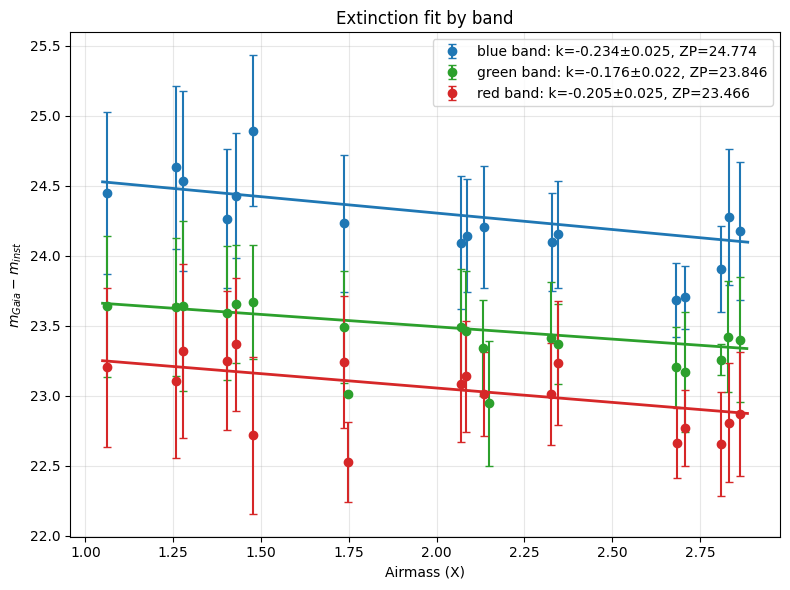

In [91]:
results = fit_extinction(df_matched_a_1_swarp_color) 

In [100]:
sky_mag_df = bg_df.copy()
zp_map = {band: results[band]["ZP"] for band in results}

No valid airmass data available.


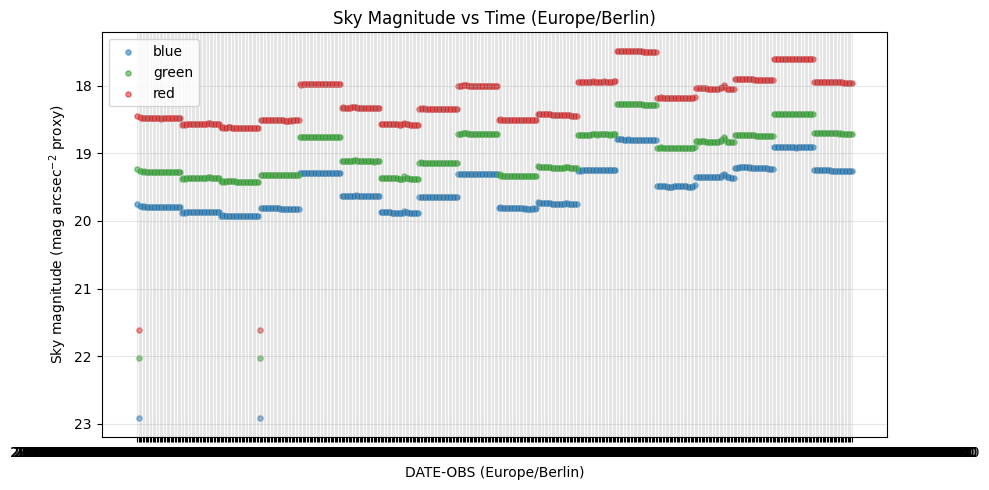

In [101]:
zp_map = {band: results[band]["ZP"] for band in results}

zp_per_row = sky_mag_df["band"].map(zp_map).to_numpy(dtype=float)

flux = (sky_mag_df["bg_median"].to_numpy(dtype=float) * sky_mag_df["gain"].to_numpy(dtype=float)) / sky_mag_df["exp_time"].to_numpy(dtype=float)
m_sky = zp_per_row - 2.5 * np.log10(flux)
sigma_m = 1.0857 * (sky_mag_df["bg_std"].to_numpy(dtype=float) / sky_mag_df["bg_median"].to_numpy(dtype=float))

sky_mag_df = sky_mag_df.copy()
sky_mag_df["flux"] = flux
sky_mag_df["m_sky"] = m_sky
sky_mag_df["sigma_m"] = sigma_m

plot_df = plot_sky_magnitude_diagnostics(sky_mag_df, None)

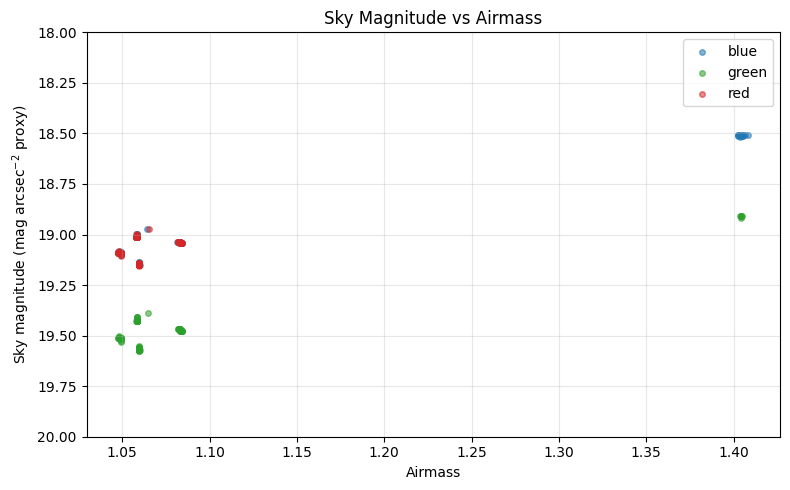

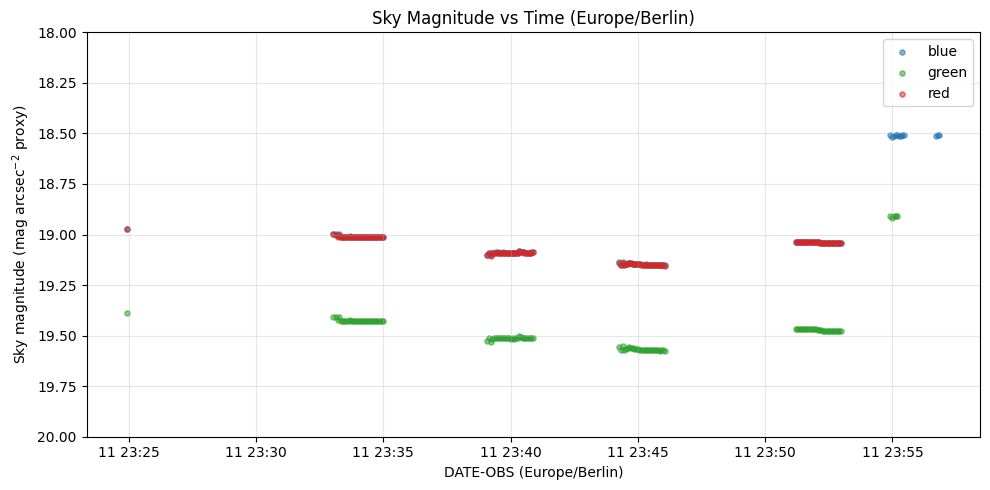

In [48]:
flux = (sky_mag_df["bg_mean"].to_numpy(dtype=float) * sky_mag_df["gain"].to_numpy(dtype=float)) / (sky_mag_df["exp_time"].to_numpy(dtype=float))
m_sky = 24 - 2.5 * np.log10(flux)
sigma_m =  (sky_mag_df["bg_std"].to_numpy(dtype=float) / sky_mag_df["bg_mean"].to_numpy(dtype=float))

sky_mag_df = sky_mag_df.copy()
sky_mag_df["flux"] = flux
sky_mag_df["m_sky"] = m_sky
sky_mag_df["sigma_m"] = sigma_m

# THEN plot
plot_df = plot_sky_magnitude_diagnostics(sky_mag_df, df_matched_a_1)

In [46]:
sky_mag_df

,filename,band,full_path,gain,exp_time,bg_median,bg_std,bg_mean,flux,m_sky,sigma_m
0,20260811T212500_273_Transient_DarkSubtracted_b...,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/w...,0.230365,3.969997,1756.0,384.10028,1763.781500,101.894343,20.388425,0.237482
1,20260811T212500_273_Transient_DarkSubtracted_g...,green,/mnt/c/Users/catal/Downloads/skyglow_evscope/w...,0.230365,3.969997,1202.0,236.09904,1206.526500,69.747723,19.802475,0.213255
2,20260811T212500_273_Transient_DarkSubtracted_r...,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/w...,0.230365,3.969997,1755.0,383.71878,1763.471300,101.836317,12.569843,0.237381
3,20260811T213304_779_Transient_DarkSubtracted_b...,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/w...,0.230365,3.969997,95.0,96.26517,104.070526,5.512507,23.555427,1.100159
4,20260811T213306_380_Transient_DarkSubtracted_b...,blue,/mnt/c/Users/catal/Downloads/skyglow_evscope/w...,0.230365,3.969997,1720.0,378.81390,1728.614400,99.805393,20.410915,0.239115
...,...,...,...,...,...,...,...,...,...,...,...
1535,20260811T225822_139_Transient_DarkSubtracted_r...,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/w...,0.230365,3.969997,2759.0,462.49112,2768.109000,160.094814,12.078657,0.181996
1536,20260811T225826_110_Transient_DarkSubtracted_r...,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/w...,0.230365,3.969997,2758.0,461.57248,2765.516400,160.036788,12.079050,0.181700
1537,20260811T225830_080_Transient_DarkSubtracted_r...,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/w...,0.230365,3.969997,2755.0,461.84076,2762.521200,159.862708,12.080232,0.182004
1538,20260811T225834_050_Transient_DarkSubtracted_r...,red,/mnt/c/Users/catal/Downloads/skyglow_evscope/w...,0.230365,3.969997,2750.0,461.11536,2757.651400,159.572577,12.082204,0.182048


# All sky camera

blue mean offset: -0.866 std: 0.189
green mean offset: -0.19 std: 0.205
red mean offset: 0.896 std: 0.189


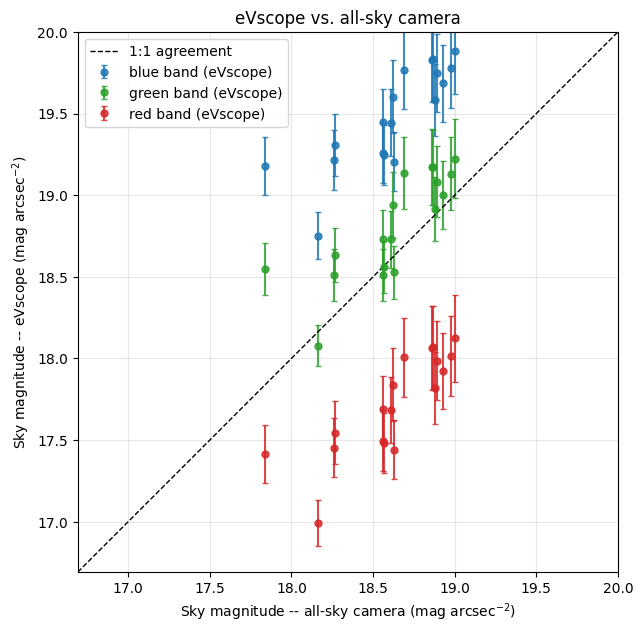

In [106]:
  # --- Real per-band extinction fit results (provided by user) ---
results = {
    "blue":  {"k": -0.2055, "ZP": 24.7314, "n": 1174},
    "green": {"k": -0.1433 , "ZP": 23.6519, "n": 1058},
    "red":   {"k": -0.1436 , "ZP": 22.9683, "n": 1155},
}
zp_map = {b: results[b]["ZP"] for b in results}

# --- Load telescope background stats ---
bkg = pd.read_csv('bkg_stats_aug_12_2.csv')
bkg['date_obs_local'] = pd.to_datetime(bkg['date_obs_local'], format='ISO8601').dt.tz_convert('Europe/Berlin')

zp_per_row = bkg['band'].map(zp_map).to_numpy(dtype=float)
flux = (bkg['bg_median'].to_numpy(dtype=float) * bkg['gain'].to_numpy(dtype=float)) / bkg['exp_time'].to_numpy(dtype=float)

# NOTE: no k*airmass term yet -- airmass isn't merged into bkg_stats.
# This uses the flat per-band ZP only.
bkg['m_sky'] = zp_per_row - 2.5 * np.log10(flux)
bkg['sigma_m'] = 1.0857 * (bkg['bg_std'].to_numpy(dtype=float) / bkg['bg_median'].to_numpy(dtype=float))

# --- Load and parse the Excel manual log ---
log = pd.read_excel('/home/catal/code/pollution/august_12_obs/Coordinates_CVM.xlsx', header=1)


# Clean column headers
log.columns = log.columns.str.strip()

# Map columns to match your down-stream code expectations
log = log.rename(columns={
    'Local time': 'local_datetime',
    'Sky Brightness [mag/arcsec²]_old camera': 'sqm_reading' # or _new camera
})

log['local_dt'] = pd.to_datetime(log['local_datetime'])
log['local_dt'] = log['local_dt'].dt.tz_localize('Europe/Berlin')
log['sqm_reading'] = pd.to_numeric(log['sqm_reading'], errors='coerce')
log = log.sort_values('local_dt')

# --- Match per band ---
tel_wide = bkg.pivot_table(
    index='date_obs_local', columns='band', values=['m_sky', 'sigma_m'], aggfunc='first'
)
tel_wide.columns = [f"{val}_{band}" for val, band in tel_wide.columns]
tel_wide = tel_wide.reset_index().sort_values('date_obs_local')

matched = pd.merge_asof(
    log, tel_wide,
    left_on='local_dt', right_on='date_obs_local',
    direction='nearest', tolerance=pd.Timedelta('3min'),
)
matched = matched.dropna(subset=['date_obs_local'])
matched.to_csv('sqm_matched_realZP.csv', index=False)

# --- Residual check ---
for b in ['blue','green','red']:
    resid = matched['sqm_reading'] - matched[f'm_sky_{b}']
    print(b, 'mean offset:', round(resid.mean(),3), 'std:', round(resid.std(),3))

# ============================================================
# PLOT 1: time series
# ============================================================
band_colors = {'blue': 'C0', 'green': 'C2', 'red': 'C3'}
band_offset = {'blue': -3, 'green': 0, 'red': 3}

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(matched['local_dt'], matched['sqm_reading'], 'k-o', ms=4,
        label='All-sky camera (reference)', zorder=3)
for b, c in band_colors.items():
    x = matched['local_dt'] + pd.to_timedelta(band_offset[b], unit='s')
    ax.errorbar(
        x, matched[f'm_sky_{b}'], yerr=matched[f'sigma_m_{b}'],
        fmt='o', ms=4, capsize=2, color=c, alpha=0.85, label=f'{b} band (eVscope)', zorder=2
    )
ax.invert_yaxis()
ax.set_xlabel('Local time (Europe/Berlin)')
ax.set_ylabel('Sky magnitude (mag arcsec$^{-2}$)')
ax.set_title('Sky magnitude: eVscope vs. reference all-sky camera')
ax.grid(alpha=0.3)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('allsky_vs_evscope_timeseries_realZP.png', dpi=150)
plt.close()

# ============================================================
# PLOT 2: 1:1 comparison, capped at 20
# ============================================================
fig, ax = plt.subplots(figsize=(6.5, 6.5))
for b, c in band_colors.items():
    ax.errorbar(
        matched['sqm_reading'], matched[f'm_sky_{b}'], yerr=matched[f'sigma_m_{b}'],
        fmt='o', ms=5, capsize=2, color=c, alpha=0.85, label=f'{b} band (eVscope)'
    )
lo = min(matched['sqm_reading'].min(), matched['m_sky_blue'].min(),
         matched['m_sky_green'].min(), matched['m_sky_red'].min()) - 0.3
hi = 20
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='1:1 agreement')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel('Sky magnitude -- all-sky camera (mag arcsec$^{-2}$)')
ax.set_ylabel('Sky magnitude -- eVscope (mag arcsec$^{-2}$)')
ax.set_title('eVscope vs. all-sky camera')
ax.grid(alpha=0.3)
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Real per-band extinction fit results
# ============================================================
results = {
    "blue":  {"k": -0.2055, "ZP": 24.7314, "n": 1174},
    "green": {"k": -0.1433 , "ZP": 23.6519, "n": 1058},
    "red":   {"k": -0.1436 , "ZP": 22.9683, "n": 1155},
}
zp_map = {b: results[b]["ZP"] for b in results}
k_map  = {b: results[b]["k"]  for b in results}

# ============================================================
# 2. Load manual log from Excel file (contains altitude & datetime)
# ============================================================
log = pd.read_excel('/home/catal/code/pollution/august_12_obs/Coordinates_CVM.xlsx', header=1)
log.columns = log.columns.str.strip()

# Map Excel column names to standard keys
log = log.rename(columns={
    'Local time': 'local_datetime',
    'Altitude': 'altitude',
    'Sky Brightness [mag/arcsec²]_old camera': 'sqm_reading' # Change to new camera if needed
})

log['local_dt'] = pd.to_datetime(log['local_datetime'])
log['local_dt'] = log['local_dt'].dt.tz_localize('Europe/Berlin')
log['sqm_reading'] = pd.to_numeric(log['sqm_reading'], errors='coerce')
log['altitude'] = pd.to_numeric(log['altitude'], errors='coerce')

# Calculate Airmass X using Pickering (2002) formula
alt_rad = np.radians(log['altitude'].to_numpy(dtype=float))
log['airmass'] = 1.0 / (np.sin(alt_rad) + 0.025 * np.exp(-11.0 * np.sin(alt_rad)))
log = log.sort_values('local_dt')

# ============================================================
# 3. Load telescope background stats & merge airmass
# ============================================================
bkg = pd.read_csv('bkg_stats_aug_12_2.csv')
bkg['date_obs_local'] = pd.to_datetime(bkg['date_obs_local'], format='ISO8601').dt.tz_convert('Europe/Berlin')

# Nearest-time merge of airmass onto background stats
bkg = pd.merge_asof(
    bkg.sort_values('date_obs_local'),
    log[['local_dt', 'airmass']].sort_values('local_dt'),
    left_on='date_obs_local', right_on='local_dt',
    direction='nearest', tolerance=pd.Timedelta('3min')
)

# Vectorized parameters per row
zp_per_row = bkg['band'].map(zp_map).to_numpy(dtype=float)
k_per_row  = bkg['band'].map(k_map).to_numpy(dtype=float)
airmass_row = bkg['airmass'].to_numpy(dtype=float)

# Flux calculation
flux = (bkg['bg_median'].to_numpy(dtype=float) * bkg['gain'].to_numpy(dtype=float)) / bkg['exp_time'].to_numpy(dtype=float)

# Magnitude calculation INCLUDING k * airmass
bkg['m_sky'] = zp_per_row + (k_per_row * airmass_row) - 2.5 * np.log10(flux)
bkg['sigma_m'] = 1.0857 * (bkg['bg_std'].to_numpy(dtype=float) / bkg['bg_median'].to_numpy(dtype=float))

# ============================================================
# 4. Match per band & compute residuals
# ============================================================
tel_wide = bkg.pivot_table(
    index='date_obs_local', columns='band', values=['m_sky', 'sigma_m'], aggfunc='first'
)
tel_wide.columns = [f"{val}_{band}" for val, band in tel_wide.columns]
tel_wide = tel_wide.reset_index().sort_values('date_obs_local')

matched = pd.merge_asof(
    log, tel_wide,
    left_on='local_dt', right_on='date_obs_local',
    direction='nearest', tolerance=pd.Timedelta('3min'),
)
matched = matched.dropna(subset=['date_obs_local'])
matched.to_csv('sqm_matched_with_airmass.csv', index=False)

# Print Residual check
for b in ['blue', 'green', 'red']:
    resid = matched['sqm_reading'] - matched[f'm_sky_{b}']
    print(b, 'mean offset:', round(resid.mean(), 3), 'std:', round(resid.std(), 3))

# ============================================================
# 5. PLOT 1: Time Series
# ============================================================
band_colors = {'blue': 'C0', 'green': 'C2', 'red': 'C3'}
band_offset = {'blue': -3, 'green': 0, 'red': 3}

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(matched['local_dt'], matched['sqm_reading'], 'k-o', ms=4,
        label='All-sky camera (reference)', zorder=3)

for b, c in band_colors.items():
    x = matched['local_dt'] + pd.to_timedelta(band_offset[b], unit='s')
    ax.errorbar(
        x, matched[f'm_sky_{b}'], yerr=matched[f'sigma_m_{b}'],
        fmt='o', ms=4, capsize=2, color=c, alpha=0.85, label=f'{b} band (eVscope)', zorder=2
    )

ax.invert_yaxis()
ax.set_xlabel('Local time (Europe/Berlin)')
ax.set_ylabel('Sky magnitude (mag arcsec$^{-2}$)')
ax.set_title('Sky magnitude: eVscope vs. reference all-sky camera (with $k \\times X$ airmass term)')
ax.grid(alpha=0.3)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('allsky_vs_evscope_timeseries_with_airmass.png', dpi=150)
plt.close()

# ============================================================
# 6. PLOT 2: 1:1 Comparison Plot
# ============================================================
fig, ax = plt.subplots(figsize=(6.5, 6.5))
for b, c in band_colors.items():
    ax.errorbar(
        matched['sqm_reading'], matched[f'm_sky_{b}'], yerr=matched[f'sigma_m_{b}'],
        fmt='o', ms=5, capsize=2, color=c, alpha=0.85, label=f'{b} band (eVscope)'
    )

lo = min(matched['sqm_reading'].min(), matched['m_sky_blue'].min(),
         matched['m_sky_green'].min(), matched['m_sky_red'].min()) - 0.3
hi = 20
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='1:1 agreement')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel('Sky magnitude -- all-sky camera (mag arcsec$^{-2}$)')
ax.set_ylabel('Sky magnitude -- eVscope (mag arcsec$^{-2}$)')
ax.set_title('eVscope vs. all-sky camera+')
ax.grid(alpha=0.3)
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('allsky_vs_evscope_1to1_with_airmass.png', dpi=150)
plt.close()

blue mean offset: -0.524 std: 0.224
green mean offset: 0.048 std: 0.225
red mean offset: 1.135 std: 0.206


Blue Band -> Mean Offset: -0.524 mag/arcsec², Std: 0.224
Green Band -> Mean Offset: 0.048 mag/arcsec², Std: 0.225
Red Band -> Mean Offset: 1.135 mag/arcsec², Std: 0.206


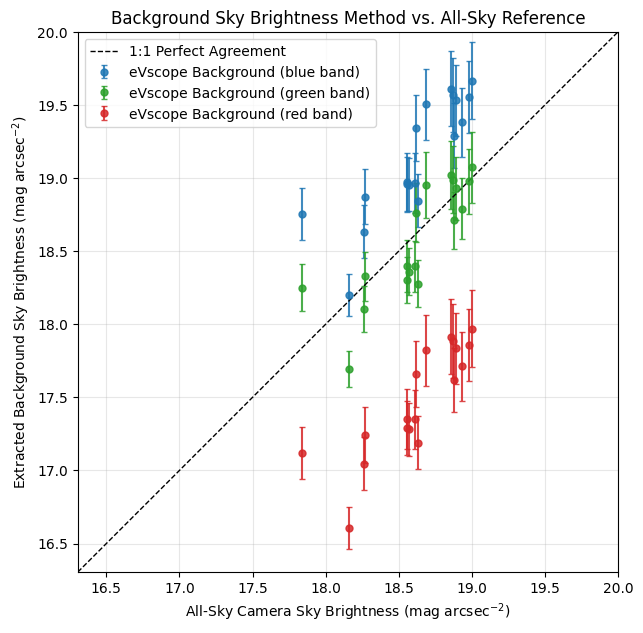

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Extinction parameters per band
# ============================================================
results = {
    "blue":  {"k": -0.2055, "ZP": 24.7314, "n": 1174},
    "green": {"k": -0.1433 , "ZP": 23.6519, "n": 1058},
    "red":   {"k": -0.1436 , "ZP": 22.9683, "n": 1155},
}
zp_map = {b: results[b]["ZP"] for b in results}
k_map  = {b: results[b]["k"]  for b in results}

# ============================================================
# 2. Load manual All-Sky Camera Log (Excel) & compute Airmass
# ============================================================
log.columns = log.columns.str.strip()

# Standardize column headers
log = log.rename(columns={
    'Local time': 'local_datetime',
    'Altitude': 'altitude',
    'Sky Brightness [mag/arcsec²]_old camera': 'sqm_reading' # Switch to '_new camera' if desired
})

log['local_dt'] = pd.to_datetime(log['local_datetime']).dt.tz_localize('Europe/Berlin')
log['sqm_reading'] = pd.to_numeric(log['sqm_reading'], errors='coerce')
log['altitude'] = pd.to_numeric(log['altitude'], errors='coerce')

# Calculate target Airmass X using Pickering (2002) formula
alt_rad = np.radians(log['altitude'].to_numpy(dtype=float))
log['airmass'] = 1.0 / (np.sin(alt_rad) + 0.025 * np.exp(-11.0 * np.sin(alt_rad)))
log = log.sort_values('local_dt')

# ============================================================
# 3. Load Telescope Background Stats & Compute Background Sky Brightness
# ============================================================
bkg = pd.read_csv('bkg_stats_aug_12_2.csv')
bkg['date_obs_local'] = pd.to_datetime(bkg['date_obs_local'], format='ISO8601').dt.tz_convert('Europe/Berlin')

# Merge target airmass onto background stats frame by nearest observation time
bkg = pd.merge_asof(
    bkg.sort_values('date_obs_local'),
    log[['local_dt', 'airmass']].sort_values('local_dt'),
    left_on='date_obs_local', right_on='local_dt',
    direction='nearest', tolerance=pd.Timedelta('3min')
)

# Convert background flux to sky brightness (mag/arcsec²) using your method
zp_per_row = bkg['band'].map(zp_map).to_numpy(dtype=float)
k_per_row  = bkg['band'].map(k_map).to_numpy(dtype=float)
airmass_row = bkg['airmass'].to_numpy(dtype=float)

flux_bg = (bkg['bg_median'].to_numpy(dtype=float) * bkg['gain'].to_numpy(dtype=float)) / bkg['exp_time'].to_numpy(dtype=float)

# Background Sky Brightness Formula
bkg['m_sky_bg'] = zp_per_row + (k_per_row * airmass_row) - 2.5 * np.log10(flux_bg)
bkg['sigma_m'] = 1.0857 * (bkg['bg_std'].to_numpy(dtype=float) / bkg['bg_median'].to_numpy(dtype=float))

# ============================================================
# 4. Pivot Background Results & Match with All-Sky Camera Log
# ============================================================
tel_wide = bkg.pivot_table(
    index='date_obs_local', columns='band', values=['m_sky_bg', 'sigma_m'], aggfunc='first'
)
tel_wide.columns = [f"{val}_{band}" for val, band in tel_wide.columns]
tel_wide = tel_wide.reset_index().sort_values('date_obs_local')

matched = pd.merge_asof(
    log, tel_wide,
    left_on='local_dt', right_on='date_obs_local',
    direction='nearest', tolerance=pd.Timedelta('3min')
).dropna(subset=['date_obs_local'])

matched.to_csv('bg_vs_allsky_matched.csv', index=False)

# Residual Summary: All-Sky minus Background Sky Brightness
for b in ['blue', 'green', 'red']:
    resid = matched['sqm_reading'] - matched[f'm_sky_bg_{b}']
    print(f"{b.capitalize()} Band -> Mean Offset: {resid.mean():.3f} mag/arcsec², Std: {resid.std():.3f}")

# ============================================================
# 5. Scatter Plot: Background Sky Brightness vs. All-Sky Camera
# ============================================================
fig, ax = plt.subplots(figsize=(6.5, 6.5))
band_colors = {'blue': 'C0', 'green': 'C2', 'red': 'C3'}

for b, c in band_colors.items():
    ax.errorbar(
        matched['sqm_reading'], matched[f'm_sky_bg_{b}'], yerr=matched[f'sigma_m_{b}'],
        fmt='o', ms=5, capsize=2, color=c, alpha=0.85, label=f'eVscope Background ({b} band)'
    )

lo = min(matched['sqm_reading'].min(), matched['m_sky_bg_blue'].min(),
         matched['m_sky_bg_green'].min(), matched['m_sky_bg_red'].min()) - 0.3
hi = 20.0

ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='1:1 Perfect Agreement')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel('All-Sky Camera Sky Brightness (mag arcsec$^{-2}$)')
ax.set_ylabel('Extracted Background Sky Brightness (mag arcsec$^{-2}$)')
ax.set_title('Background Sky Brightness Method vs. All-Sky Reference')
ax.grid(alpha=0.3)
ax.legend()
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('bg_vs_allsky_comparison.png', dpi=150)
plt.show()